# Transfer: can an existing model annotate newly arrived samples?

Eleven conventional ChIP-seq ENCODE samples, split into seven initial and four incoming, several different ways.

Seven methods - ChromHMM, KMeans and BMM3 on **HOMER**, **MACS2** and **Omnipeak** peak calls - each **Init** on the initial seven, **updated** from that fit on the four incoming alone, and **refitted** from scratch on all eleven: twenty-one arms.

The `updated` arm sees the incoming samples alone - a lab that kept the model and not the cohort. It continues the Init fit; the refit is the same data fitted from scratch, so `updated` against the refit is exactly what warm-starting costs.


## Setup

In [1]:
%config InlineBackend.figure_format = "retina"

import os
import sys

# Add scripts/analysis to path
sys.path.insert(0, os.path.abspath("scripts/analysis"))

import transfer
from display import header, show, show_all

In [2]:
os.chdir(os.path.expanduser(transfer.DATA_DIR))

OUT = os.path.join("out", "transfer")
PLOTS = os.path.join(OUT, "plots")

RECOMPUTE = False

## 1. The run

In [3]:
report, frames = transfer.load_or_run(OUT, recompute=RECOMPUTE)
summary = report["summary"]

Transfer experiment: 15 states, seed 42, 7 splits
  preprocess monocytes ... 0.8s
  binarize monocytes at 100 bp ... 4.5s
  preprocess spleen ... 0.8s
  binarize spleen at 100 bp ... 4.6s
  preprocess neurosphere ... 0.7s
  binarize neurosphere at 100 bp ... 3.9s
  preprocess imr90 ... 0.8s
  binarize imr90 at 100 bp ... 5.8s
  preprocess sigmoid_colon ... 0.6s
  binarize sigmoid_colon at 100 bp ... 3.5s
  preprocess adrenal_gland ... 0.7s
  binarize adrenal_gland at 100 bp ... 4.9s
  preprocess tibial_nerve ... 0.7s
  binarize tibial_nerve at 100 bp ... 4.7s
  preprocess heart_left_ventricle ... 0.8s
  binarize heart_left_ventricle at 100 bp ... 5.1s
  preprocess heart_right_ventricle ... 0.8s
  binarize heart_right_ventricle at 100 bp ... 5.1s
  preprocess substantia_nigra ... 0.7s
  binarize substantia_nigra at 100 bp ... 4.7s
  preprocess temporal_lobe ... 0.8s
  binarize temporal_lobe at 100 bp ... 5.6s
  binarize monocytes at 100 bp ... 3.7s
  binarize spleen at 100 bp ... 2.9s
 

Splits:   0%|          | 0/7 [00:00<?, ?it/s]

split1: 7 initial, 4 incoming
  count patterns on chr1 ... 2.6s
  split1: chromhmm ... 271.3s
  split1: omni_kmeans ... 17.3s
  split1: omni_bmm3 ... 62.5s
  split1: homer_kmeans ... 17.2s
  split1: homer_bmm3 ... 58.5s
  split1: macs2_kmeans ... 17.3s
  split1: macs2_bmm3 ... 77.1s
split2: 7 initial, 4 incoming
  count patterns on chr1 ... 2.7s
  split2: chromhmm ... 368.5s
  split2: omni_kmeans ... 17.6s
  split2: omni_bmm3 ... 59.7s
  split2: homer_kmeans ... 17.4s
  split2: homer_bmm3 ... 59.1s
  split2: macs2_kmeans ... 17.4s
  split2: macs2_bmm3 ... 77.7s
split3: 7 initial, 4 incoming
  count patterns on chr1 ... 2.8s
  split3: chromhmm ... 350.7s
  split3: omni_kmeans ... 17.5s
  split3: omni_bmm3 ... 64.1s
  split3: homer_kmeans ... 17.3s
  split3: homer_bmm3 ... 58.0s
  split3: macs2_kmeans ... 17.2s
  split3: macs2_bmm3 ... 78.6s
split4: 7 initial, 4 incoming
  count patterns on chr1 ... 2.9s
  split4: chromhmm ... 290.9s
  split4: omni_kmeans ... 16.9s
  split4: omni_bmm3 ..

,value
states,15
learn_chroms,chr1
ChromHMM bin (bp),200
pattern bin (bp),100
peak bin (bp),100
seed,42
splits,7
incoming per split,adrenal_gland+imr90+sigmoid_colon+tibial_nerve...
arms,21
tolerance,0.02


### The numbers

The first table is the decision the experiment exists to make: how much of its state space survives refitting. One row per arm, for each of the two scenarios that have a refit to lose against.

The last table is what the warm start itself costs: the warm fit's objective against a fresh fit at the full restart budget on the very same counts - inertia for K-means, log-likelihood for the mixtures - and the wall time of each. ChromHMM has no restart budget to fall short of and does not appear.


In [4]:
transfer.summary_table(report, frames).round(3)

stability  stability_noqh
method       scenario                                     
omni_kmeans  Init                    0.981           0.972
             updated (new only)      0.980           0.970
omni_bmm3    Init                    0.984           0.972
             updated (new only)      0.983           0.971
chromhmm     Init                    0.989           0.987
             updated (new only)      0.987           0.989
homer_kmeans Init                    0.992           0.988
             updated (new only)      0.992           0.988
homer_bmm3   Init                    0.994           0.987
             updated (new only)      0.994           0.986
macs2_kmeans Init                    0.987           0.974
             updated (new only)      0.986           0.974
macs2_bmm3   Init                    0.986           0.982
             updated (new only)      0.987           0.985

In [5]:
transfer.objective_table(frames).round(3)

,warm objective,fresh objective,warm is worse by (%),warm fit (s),fresh fit (s)
method,,,,,
KMeans (Omni) updated,1.804821e+05,1.554527e+05,18.327,0.010,1.071
BMM3 (Omni) updated,-1.935932e+07,-1.915381e+07,1.068,0.184,13.920
KMeans (HOMER) updated,3.290862e+04,2.876112e+04,15.673,0.010,1.061
BMM3 (HOMER) updated,-9.094555e+06,-9.077647e+06,0.185,0.101,12.336
KMeans (MACS2) updated,6.646824e+04,4.536644e+04,48.272,0.010,1.068
BMM3 (MACS2) updated,-1.378680e+07,-1.372651e+07,0.344,0.106,17.378


### Plots

In [6]:
figures = transfer.plots(frames, summary, PLOTS)

  saved out/transfer/plots/cross_sample_kappa_full.png
  saved out/transfer/plots/cross_sample_kappa_noqh.png
  saved out/transfer/plots/cost.png
  saved out/transfer/plots/state_kappa.png
  saved out/transfer/plots/state_kappa_init.png
  saved out/transfer/plots/state_kappa_summary_init.png
  saved out/transfer/plots/state_kappa_updated.png
  saved out/transfer/plots/state_kappa_summary_updated.png
  saved out/transfer/plots/stability_kappa_full_init.png
  saved out/transfer/plots/stability_kappa_full_updated.png
  saved out/transfer/plots/stability_kappa_noqh_init.png
  saved out/transfer/plots/stability_kappa_noqh_updated.png


### Show

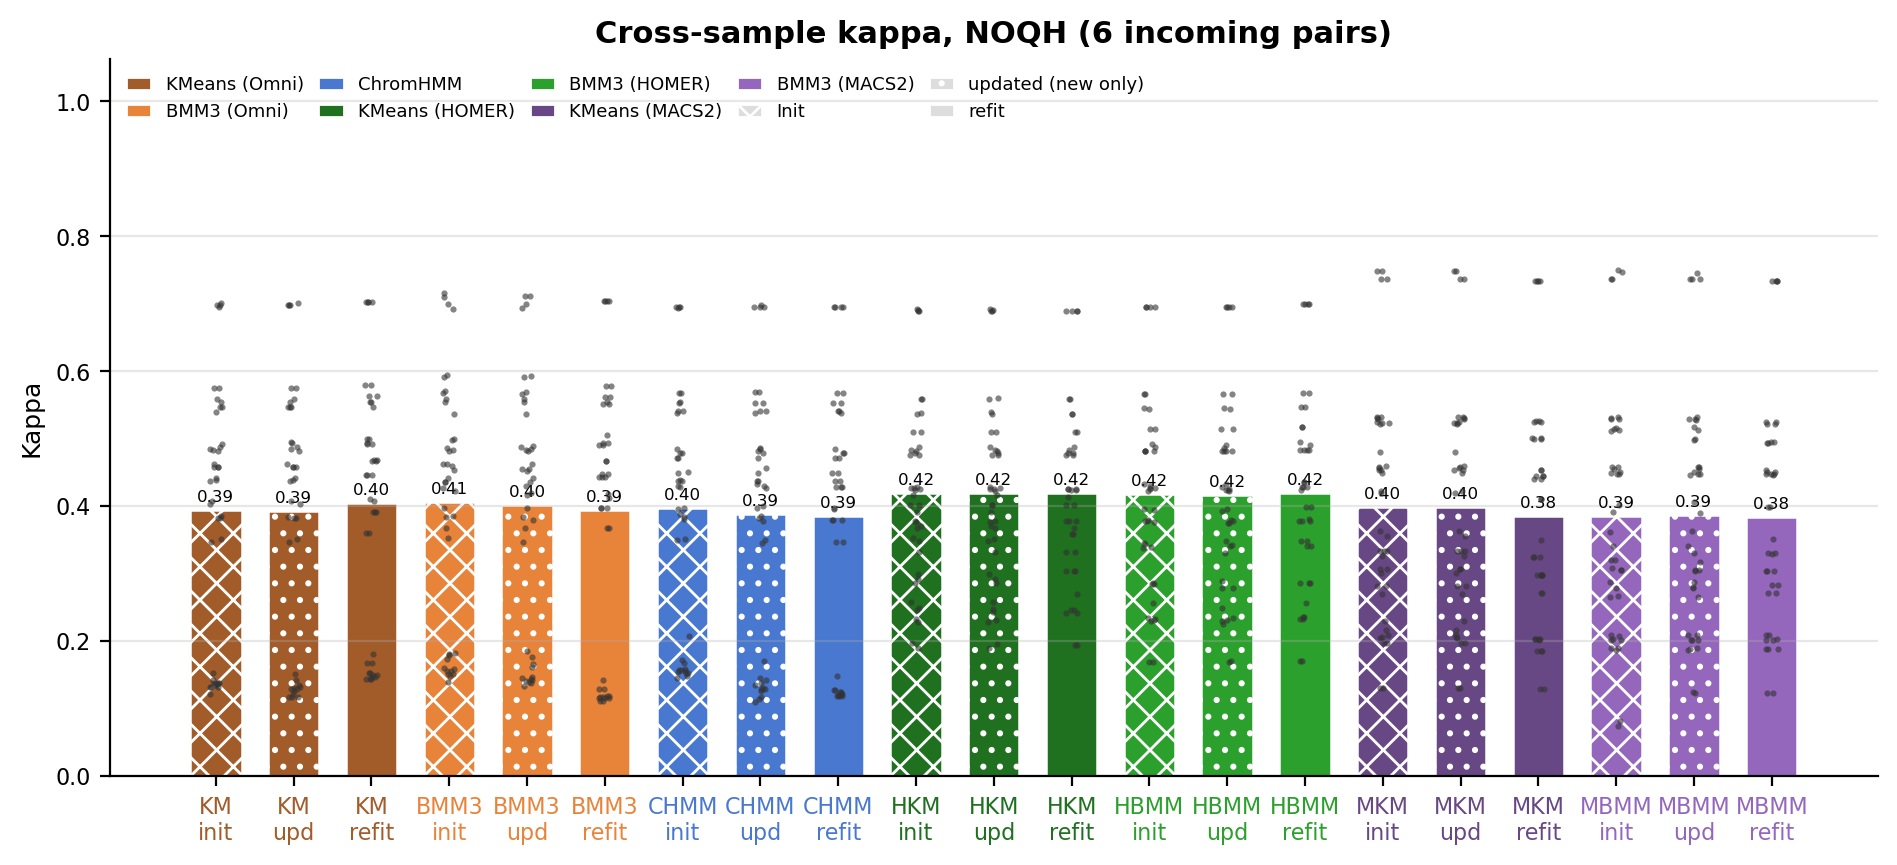

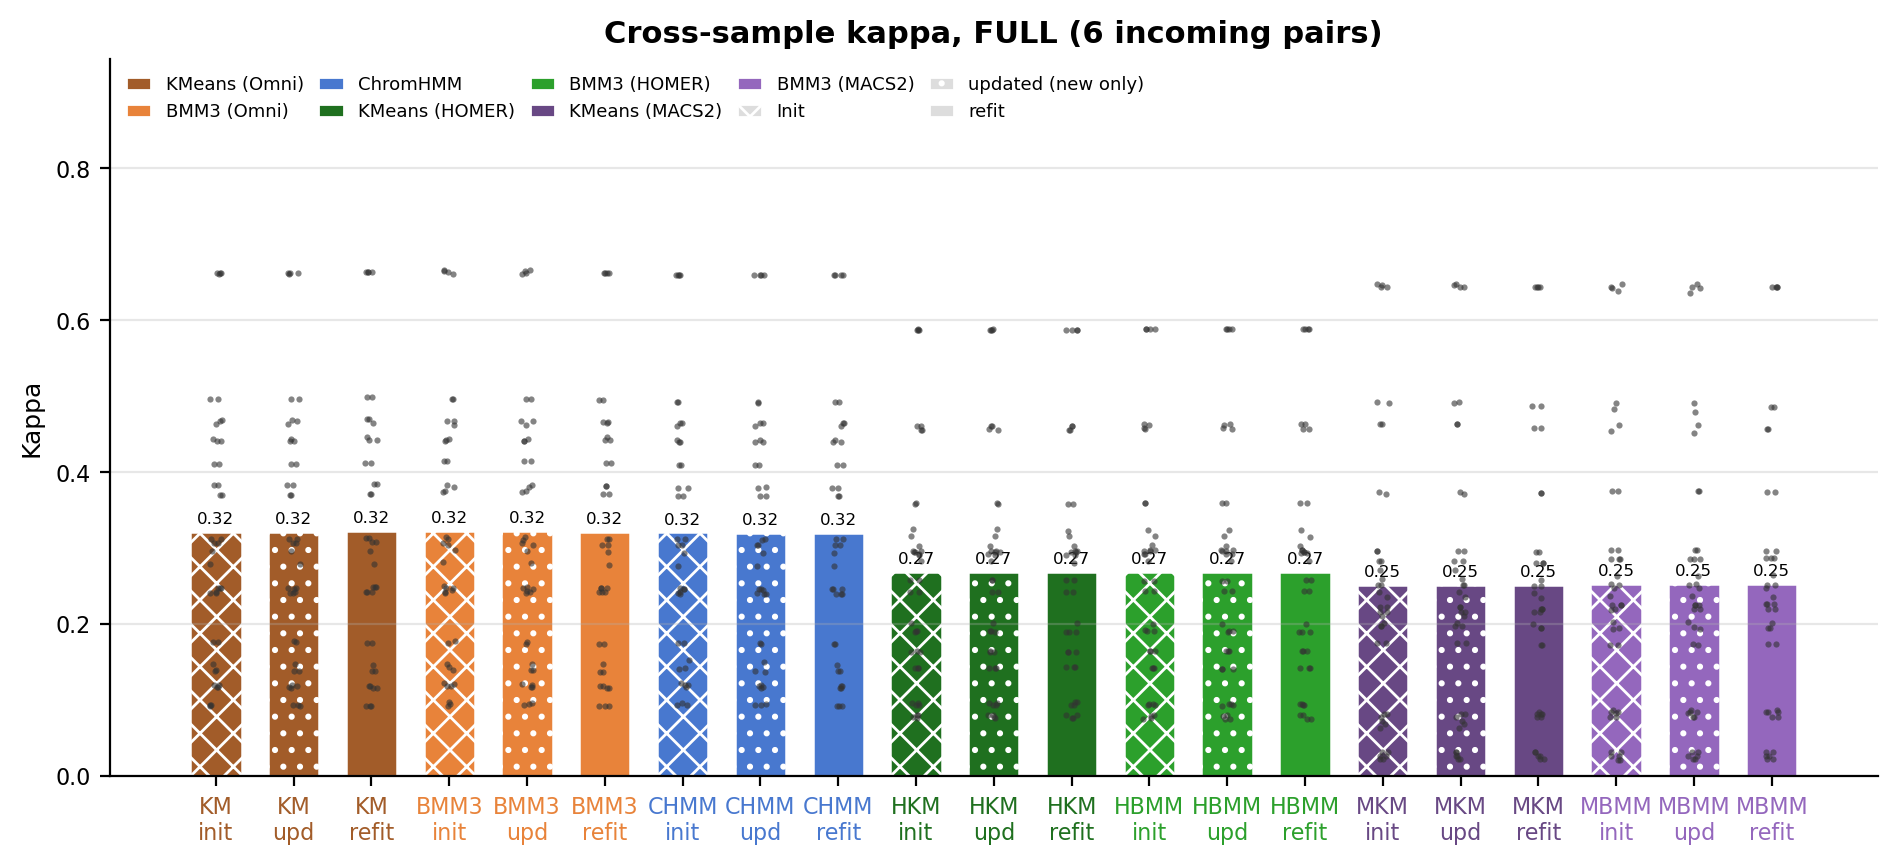

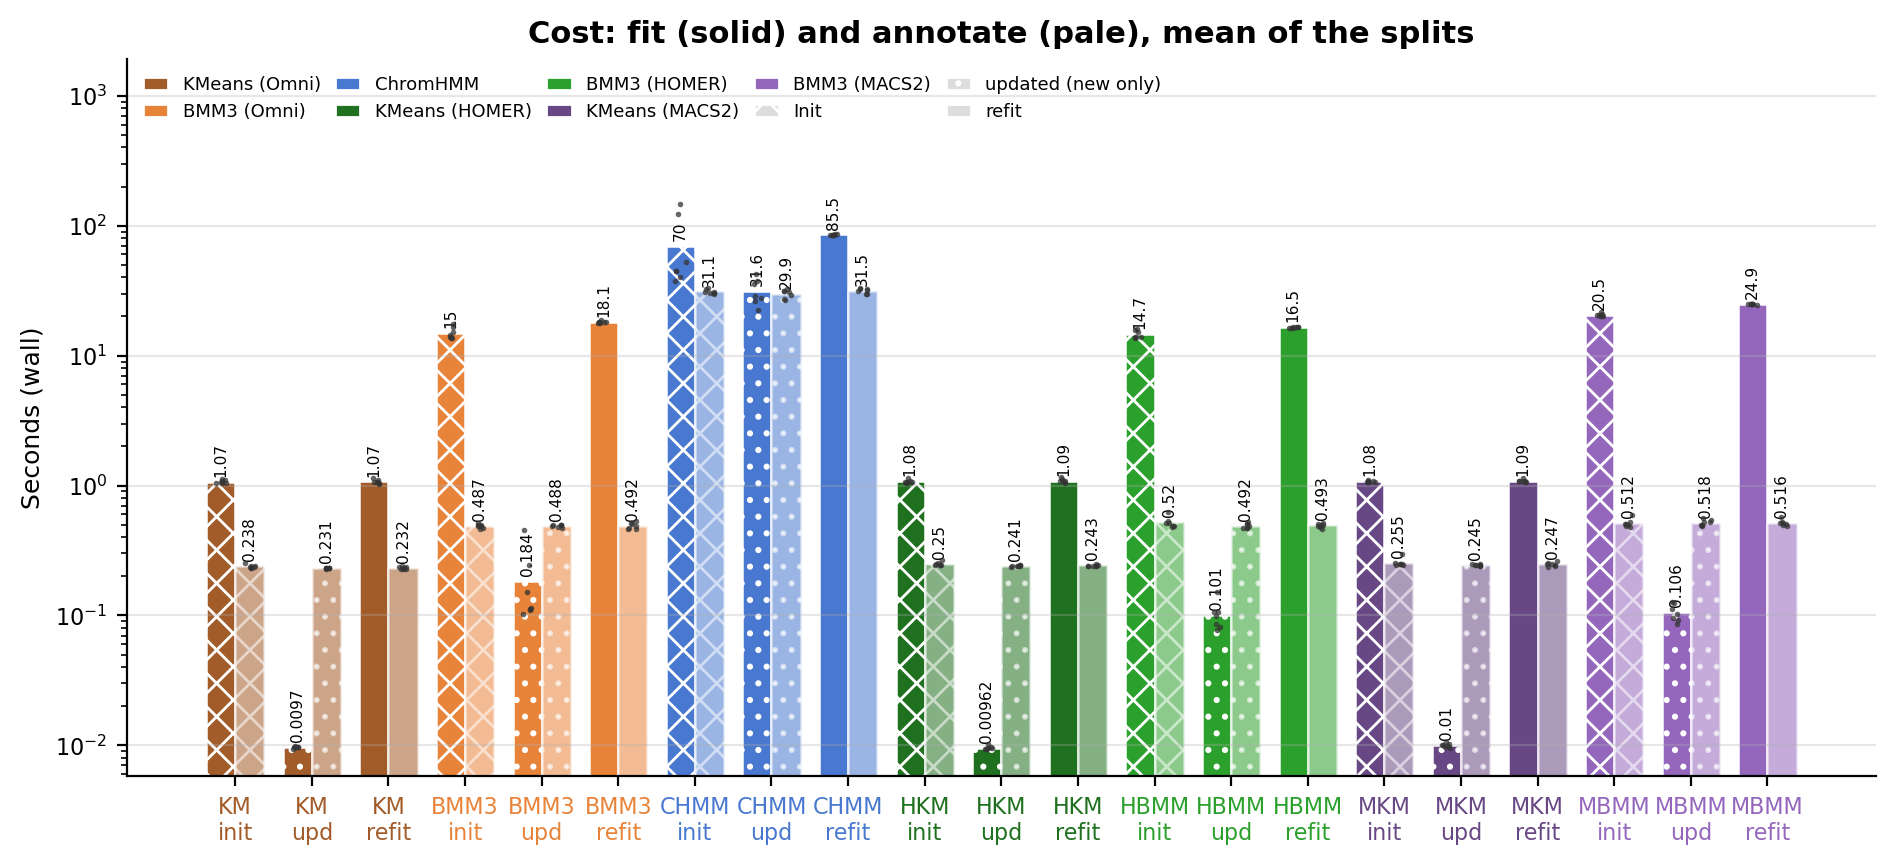

In [7]:
header("Cross-sample agreement and cost")
show_all(["cross_sample_kappa_noqh.png", "cross_sample_kappa_full.png",
          "cost.png"], base=PLOTS, width=900);

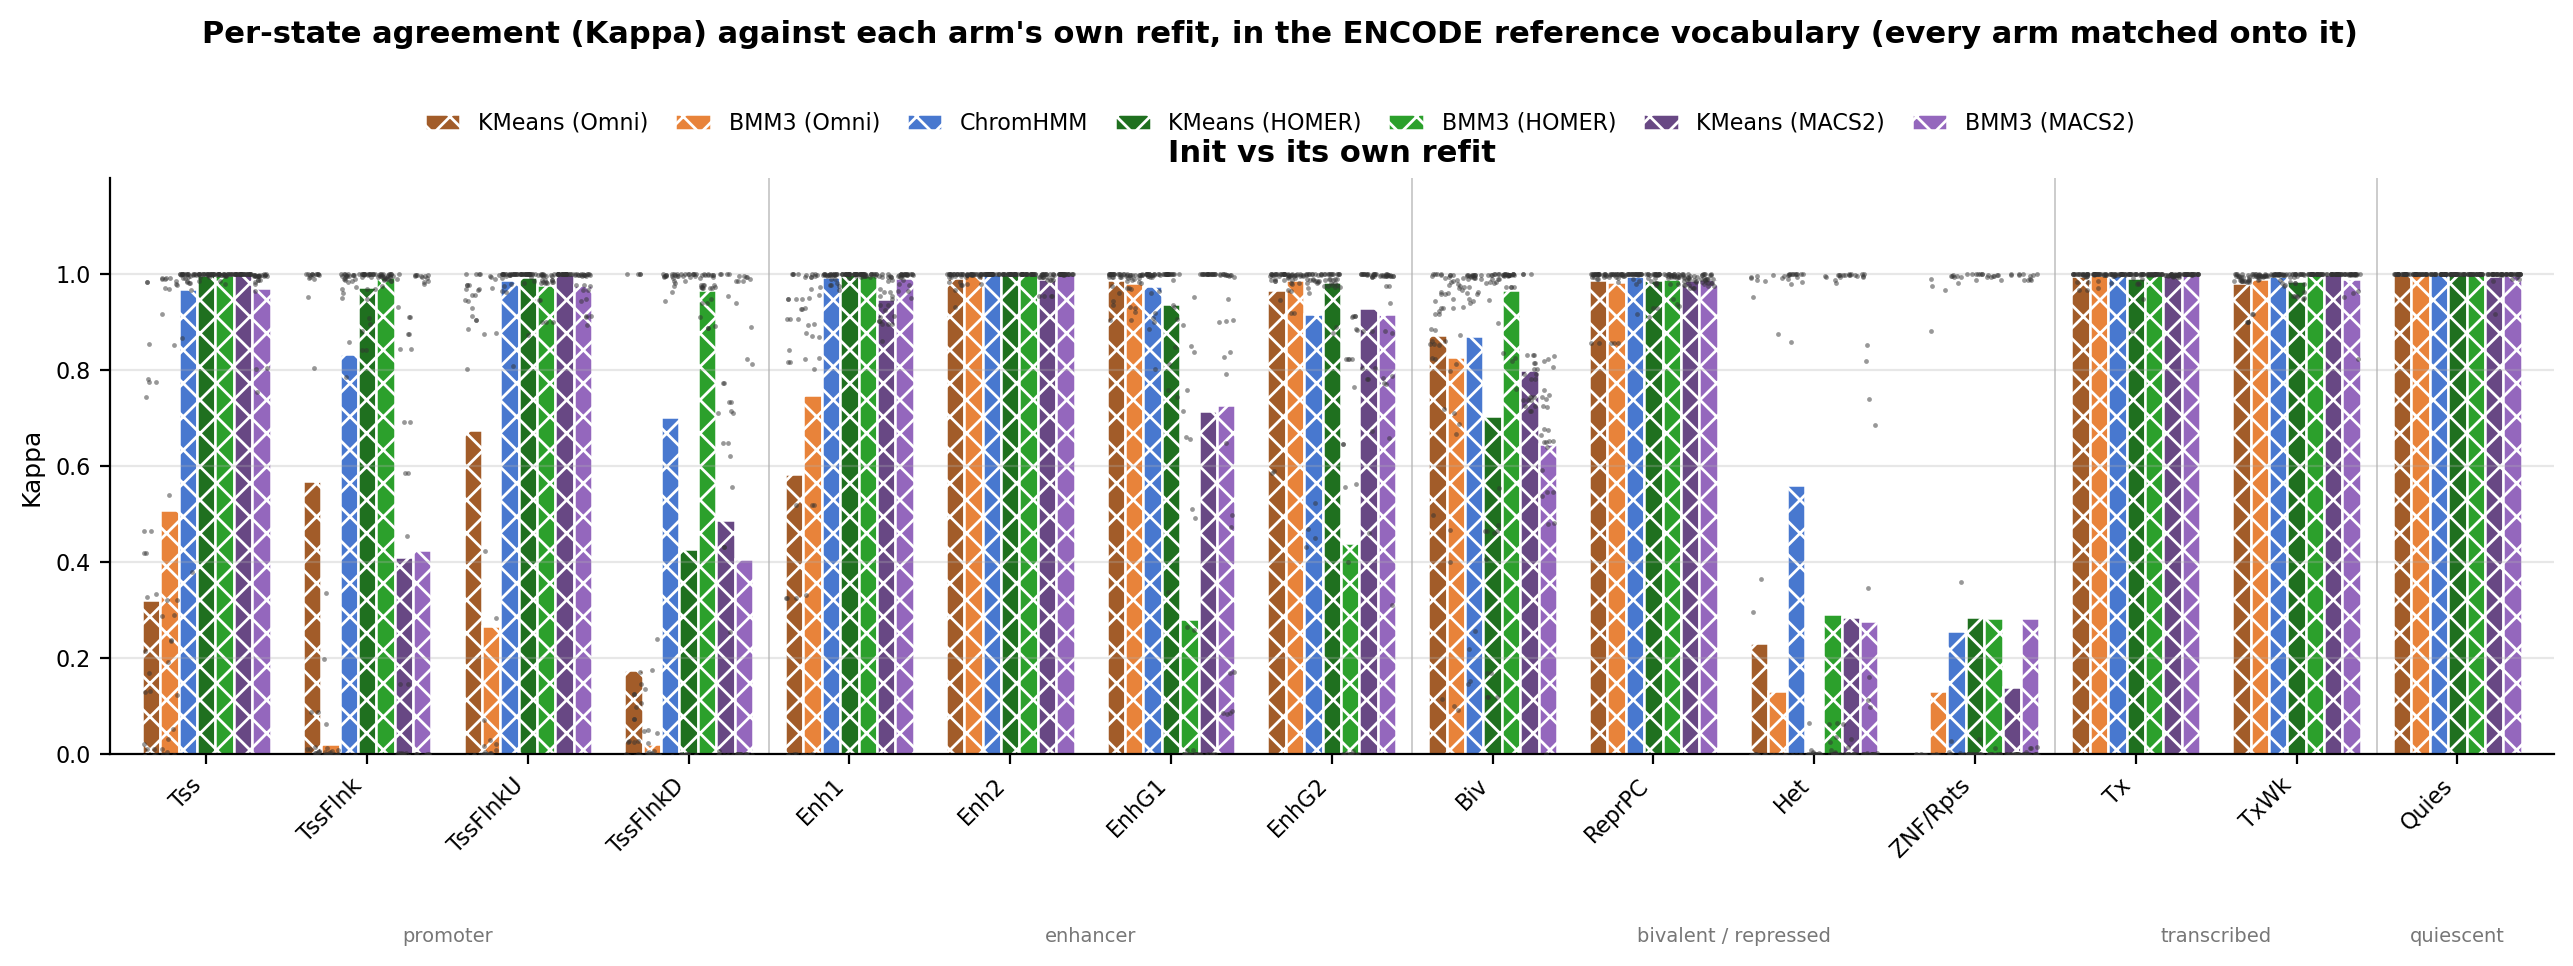

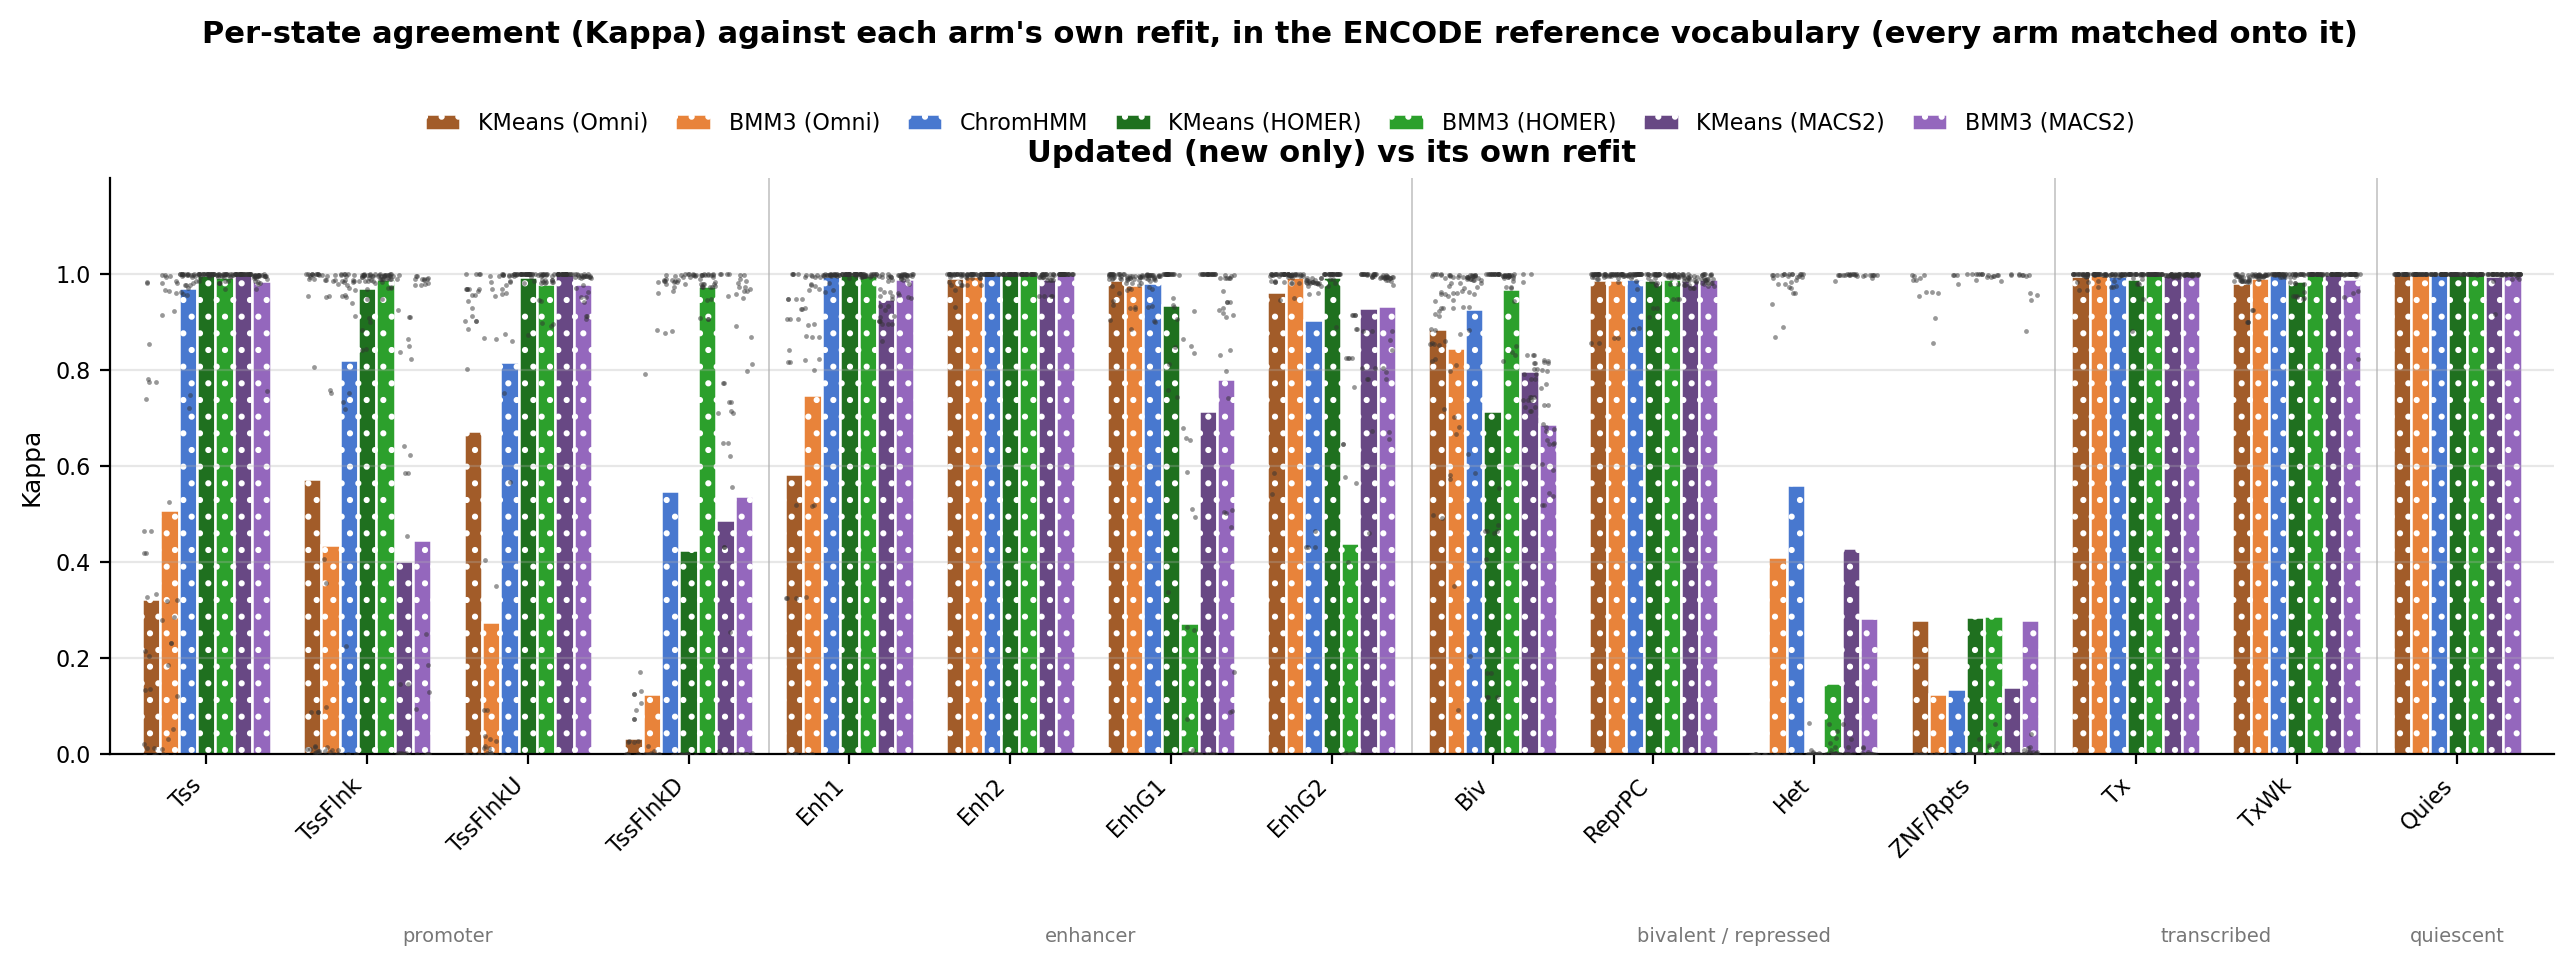

In [8]:
header("Per-state agreement in the shared ENCODE reference vocabulary")
show_all(["state_kappa_init.png", "state_kappa_updated.png"], base=PLOTS, width=1100);

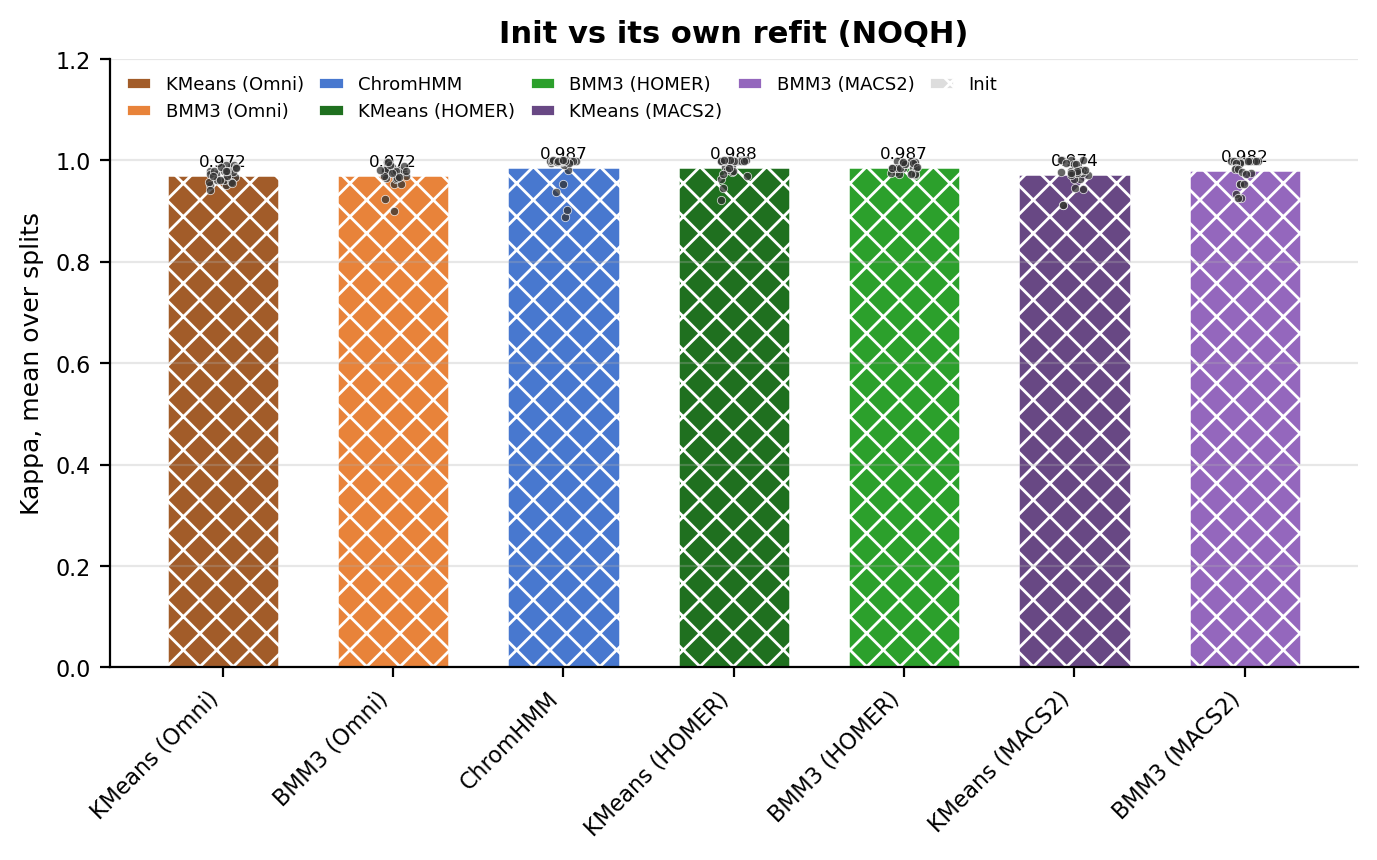

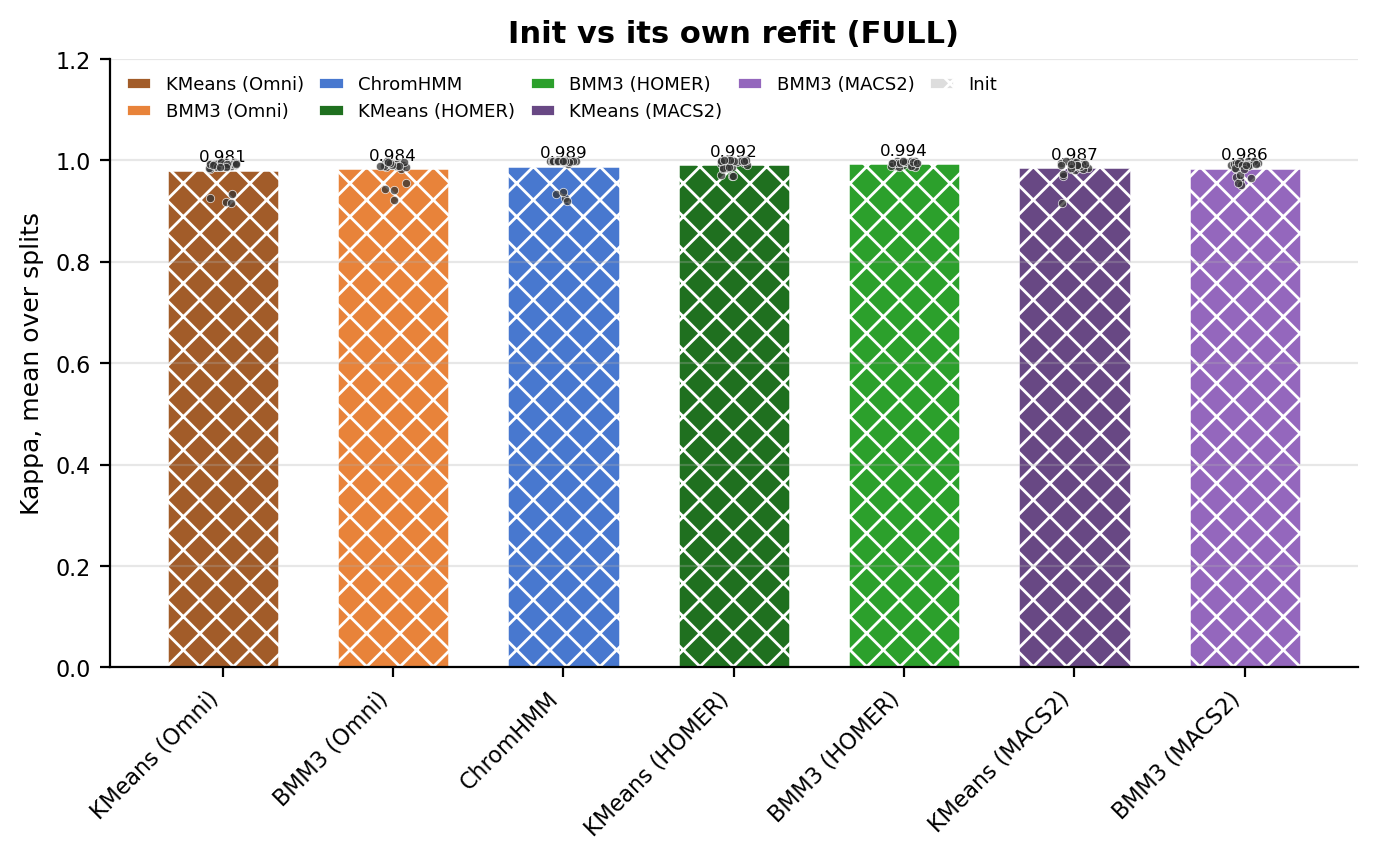

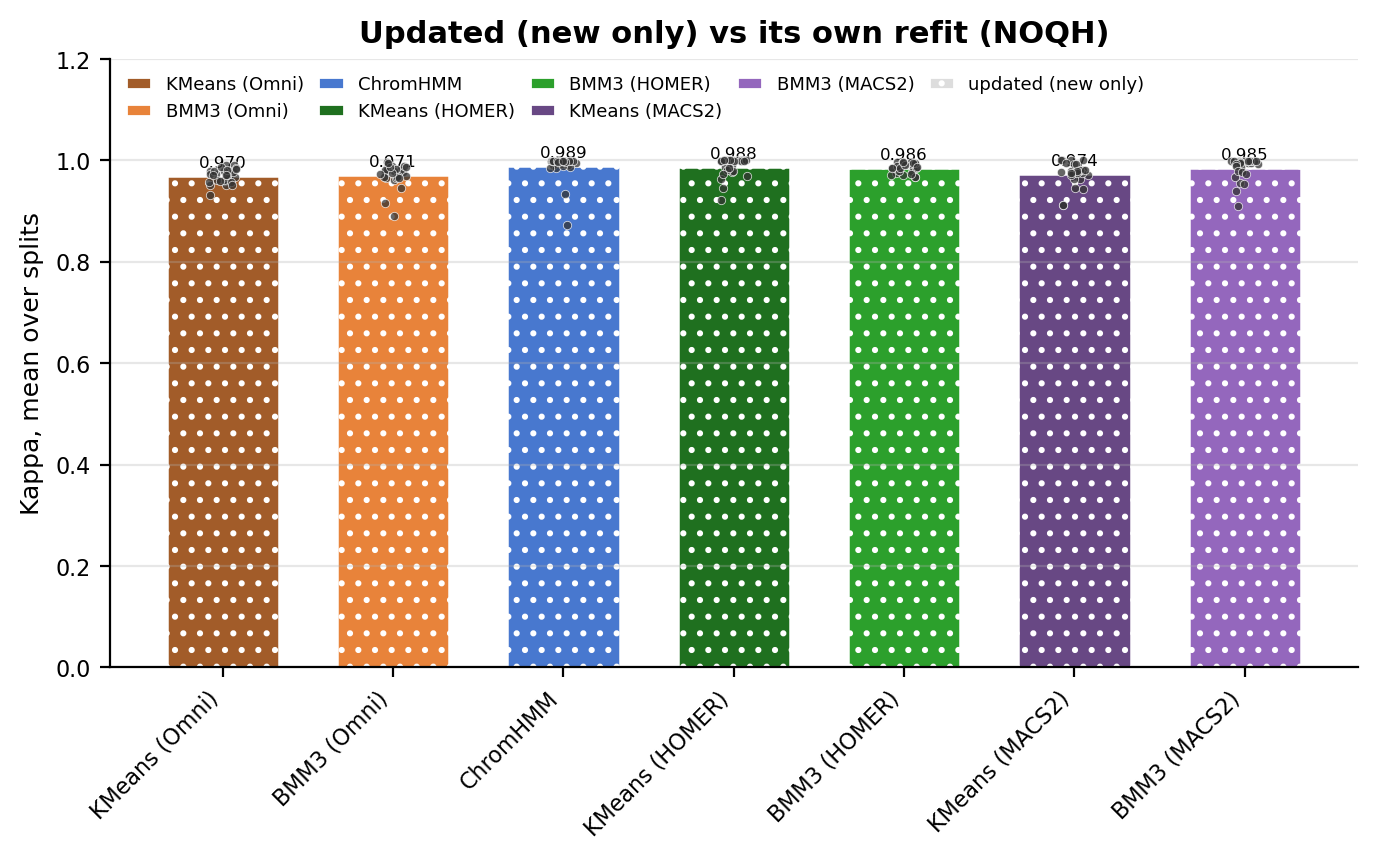

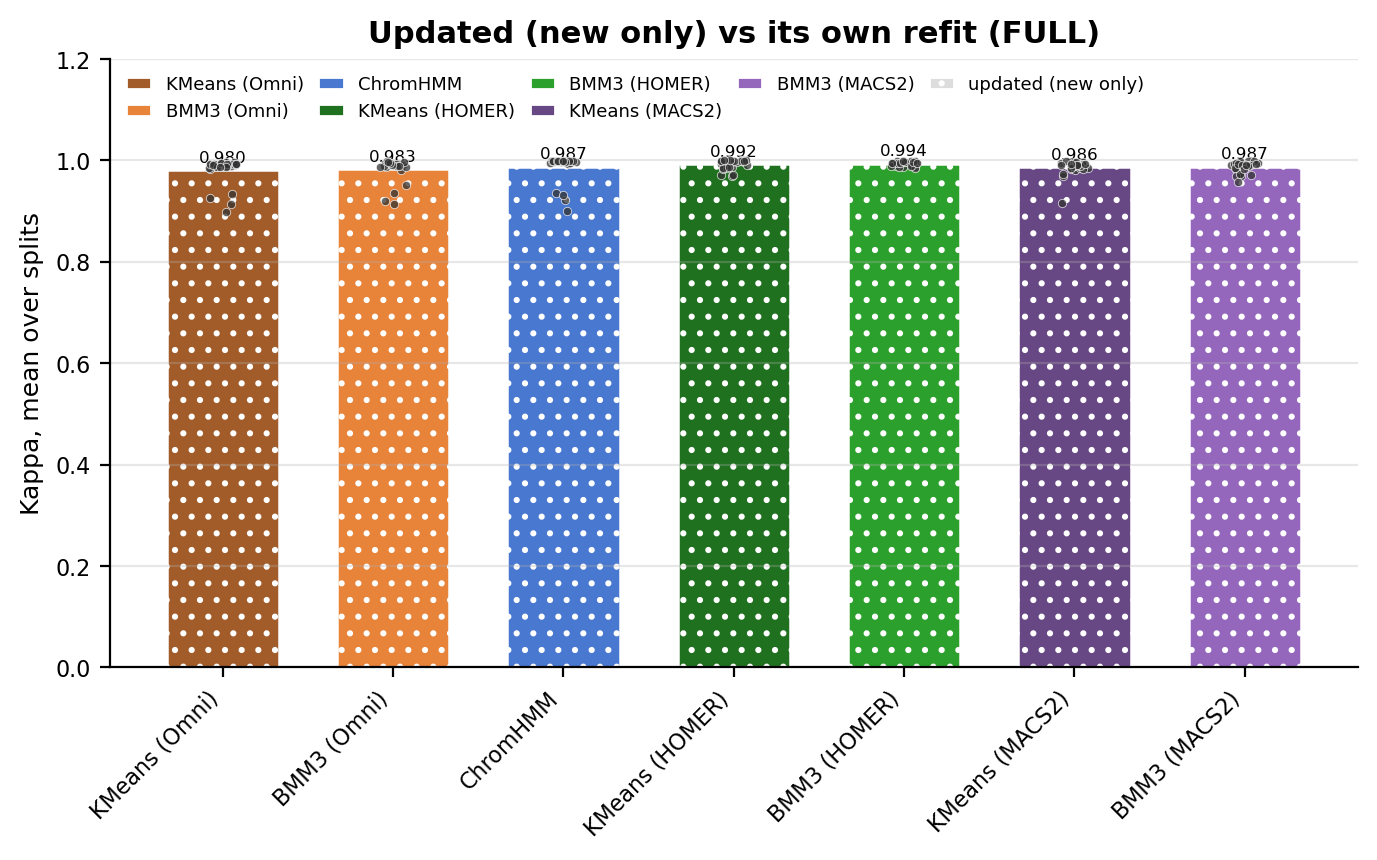

In [9]:
header("State-space stability: mean per-state agreement (Kappa) against each arm's own refit")
show_all([f"stability_{m}_{d}_{s}.png" for s in transfer.ARMS_OF_SCENARIO
          for m in ("kappa",) for d in ("noqh", "full")], base=PLOTS, width=700);

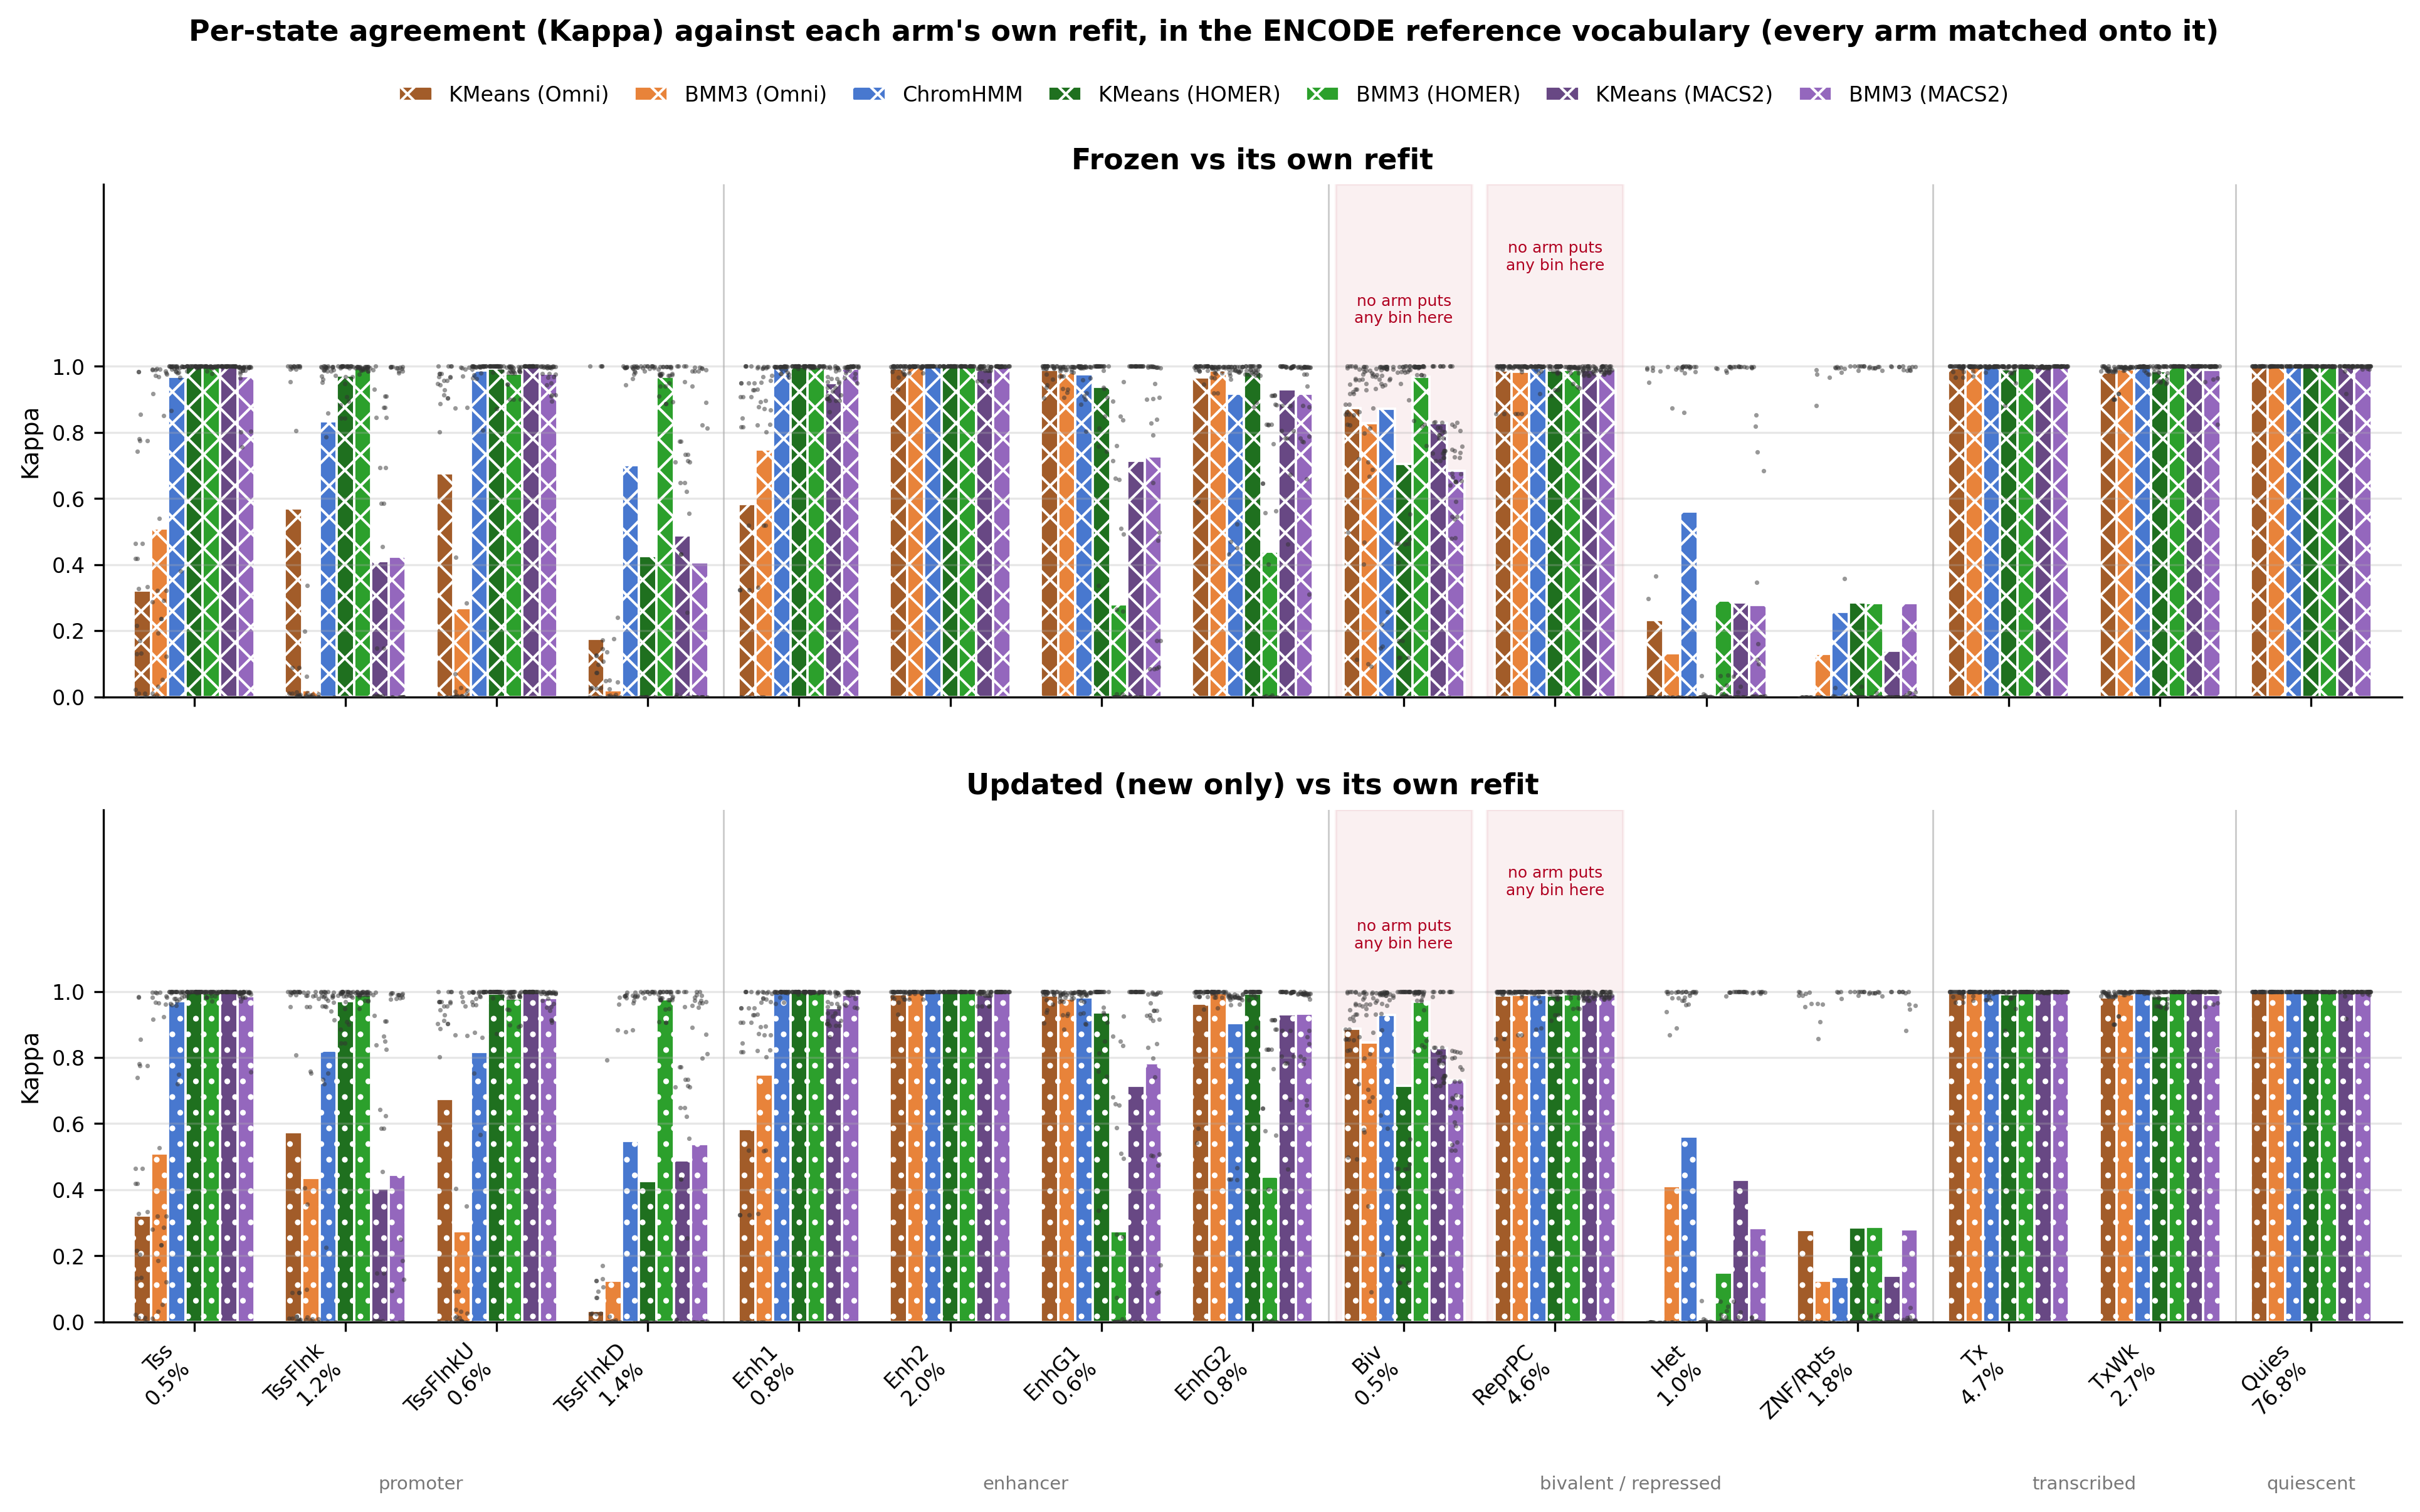

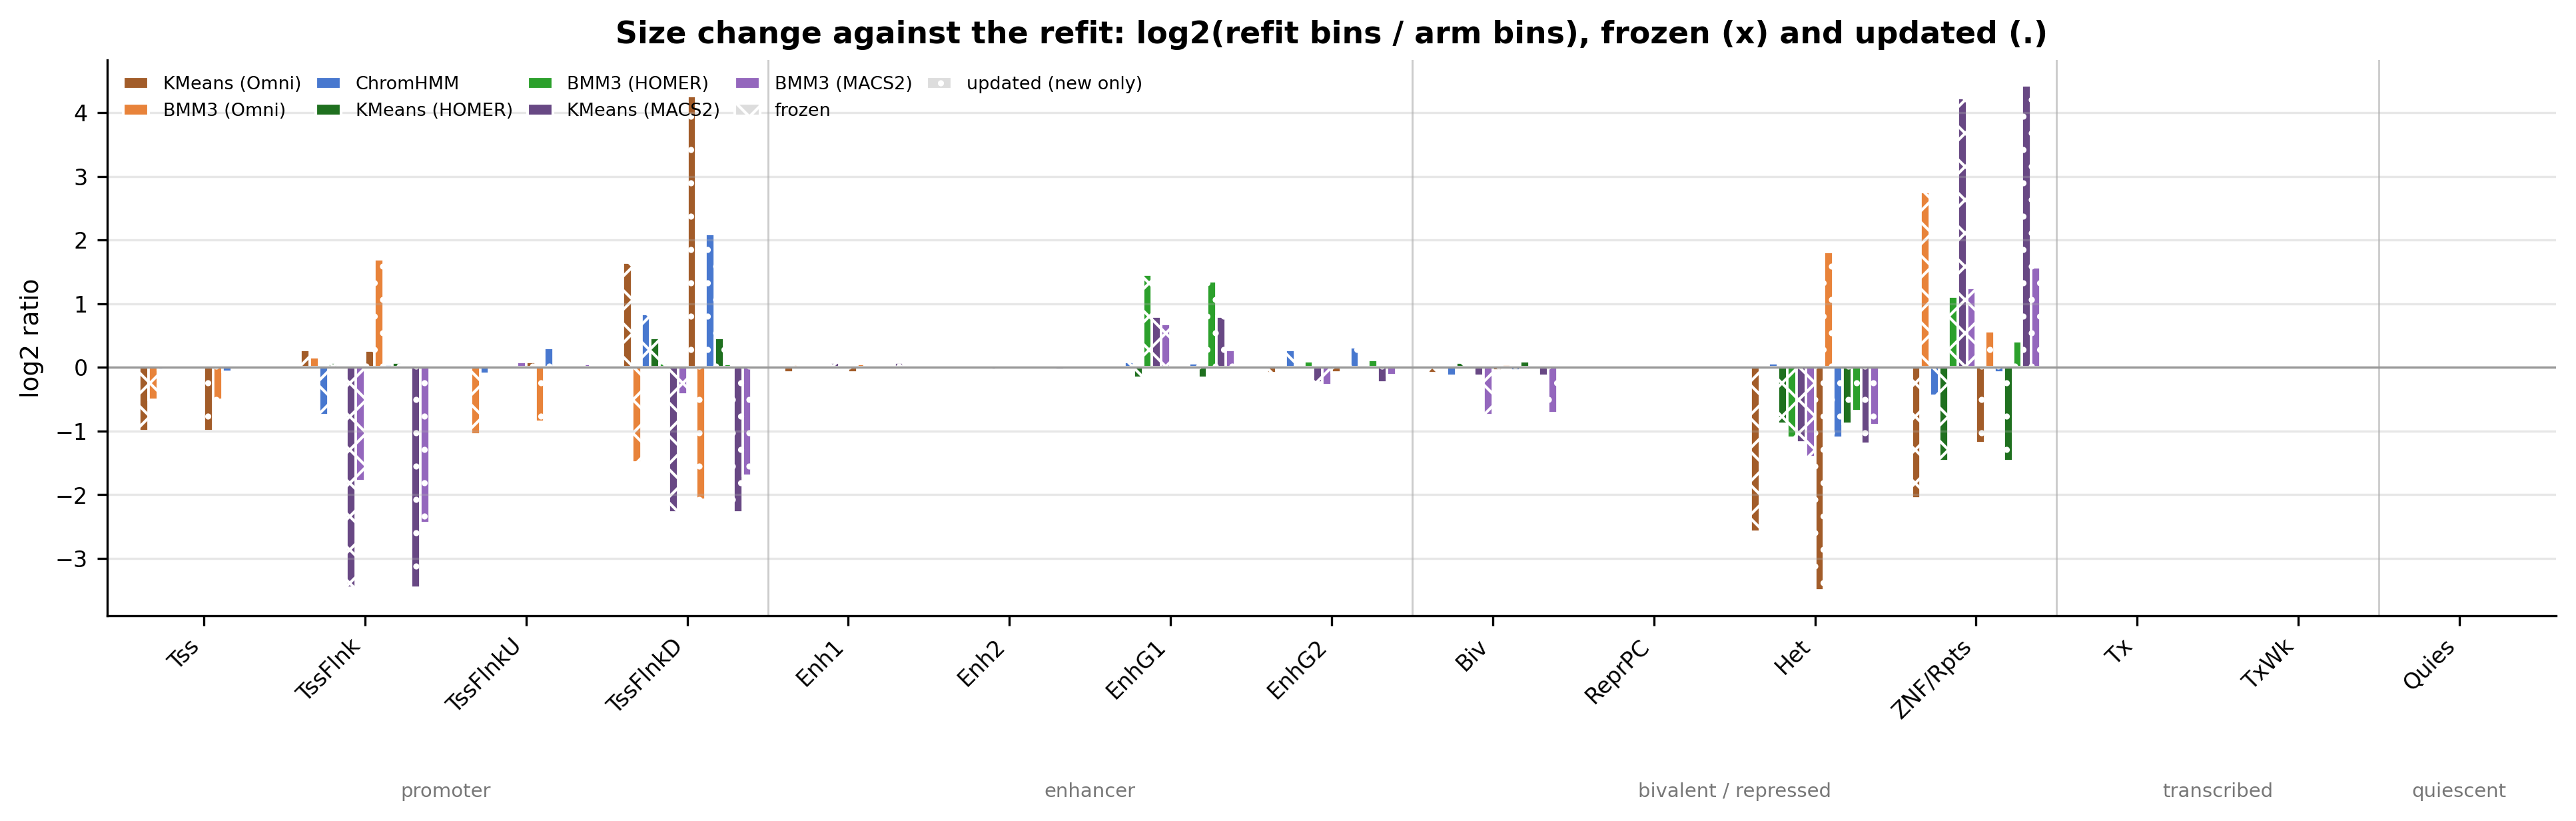

In [10]:
header("Per-state agreement in the shared ENCODE reference vocabulary")
show_all(["state_kappa.png", "state_size_ratio.png"], base=PLOTS, width=1100);

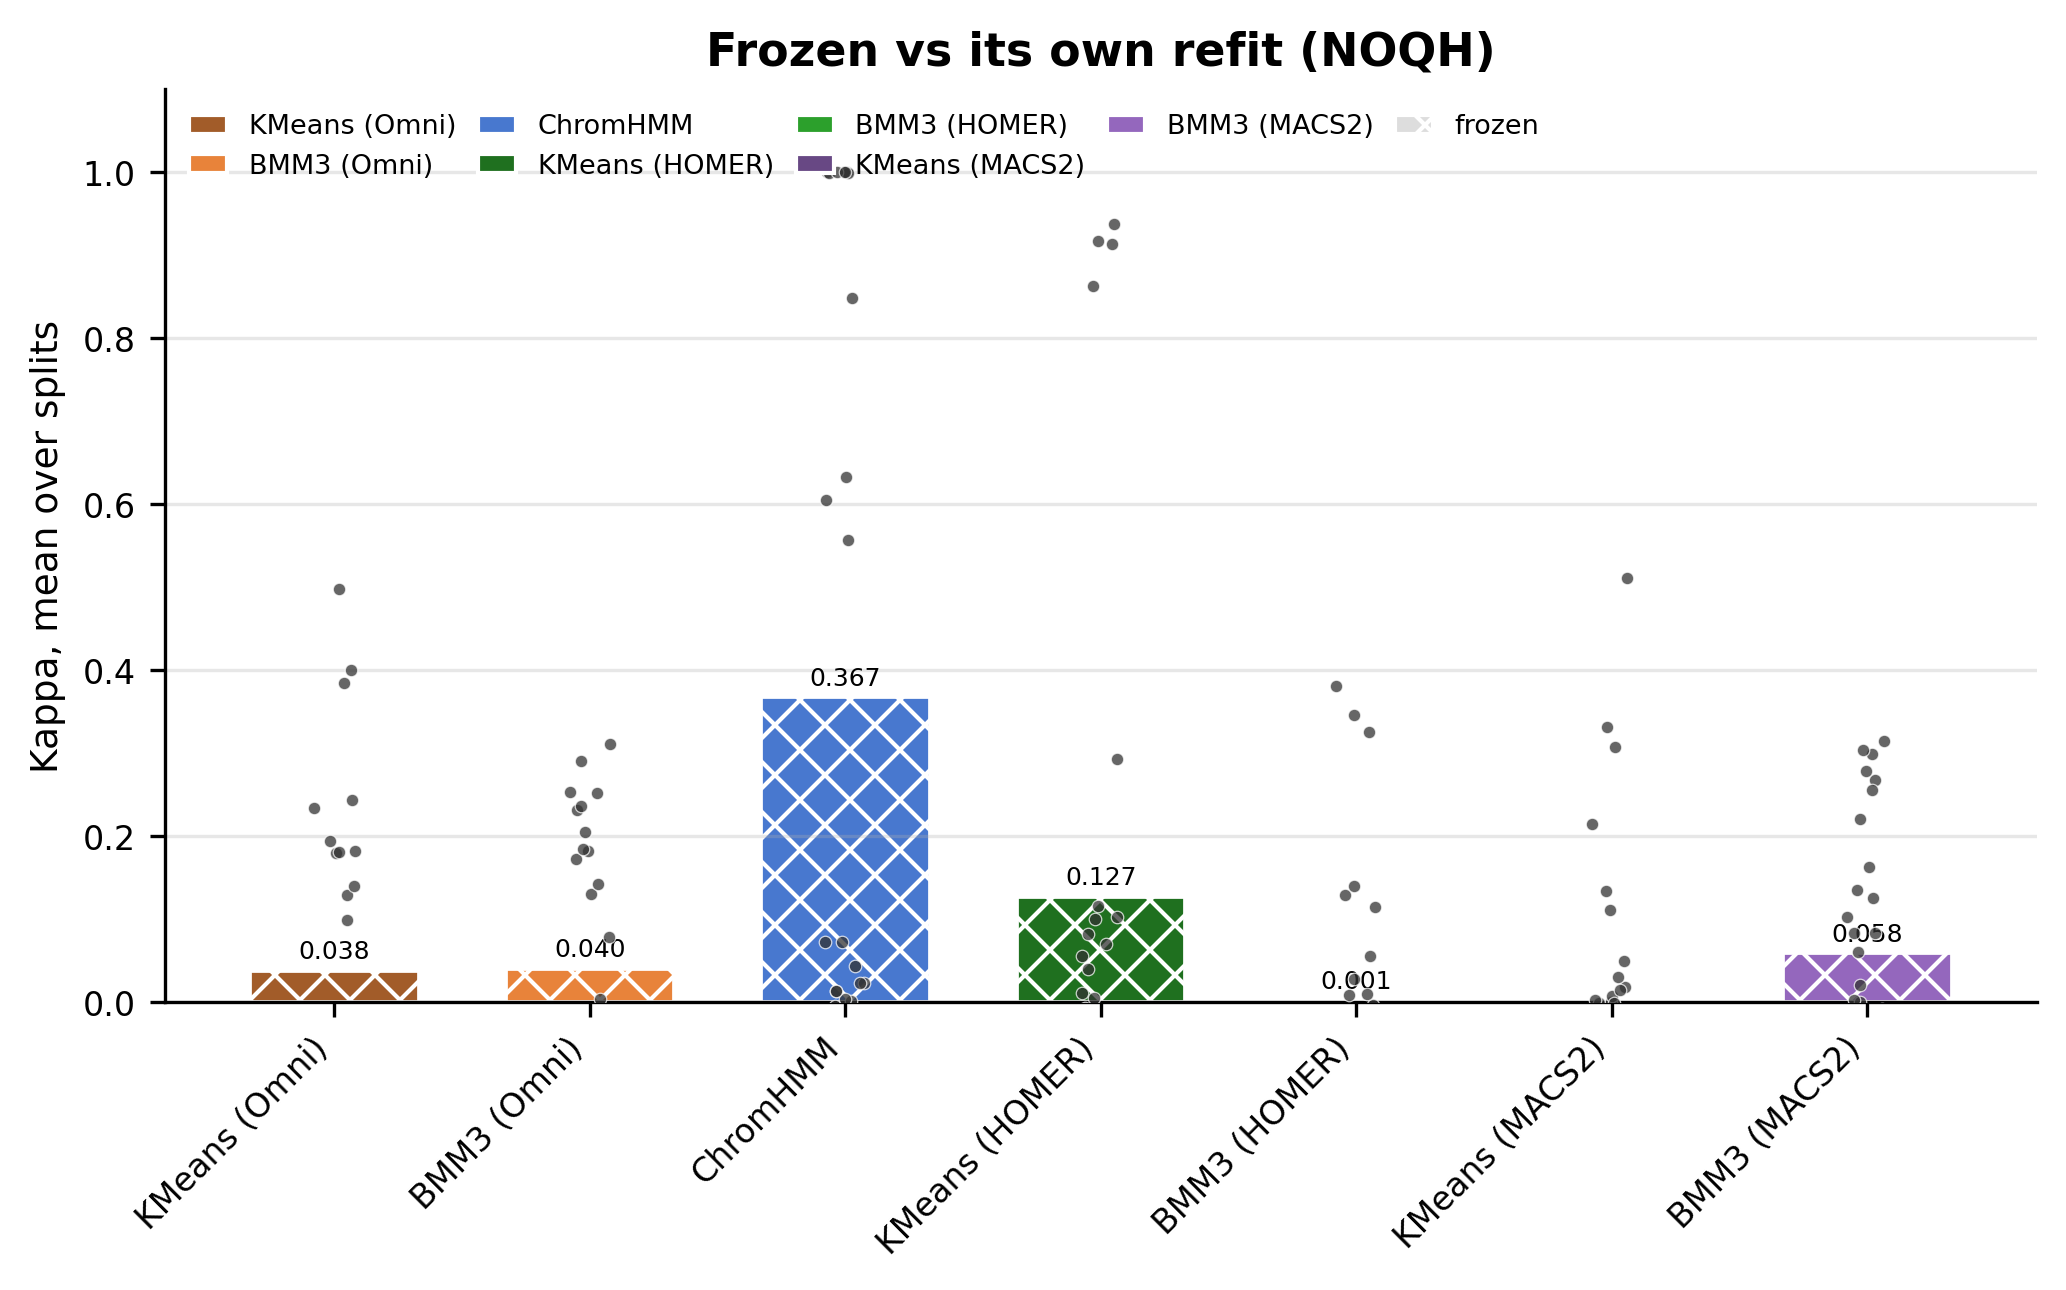

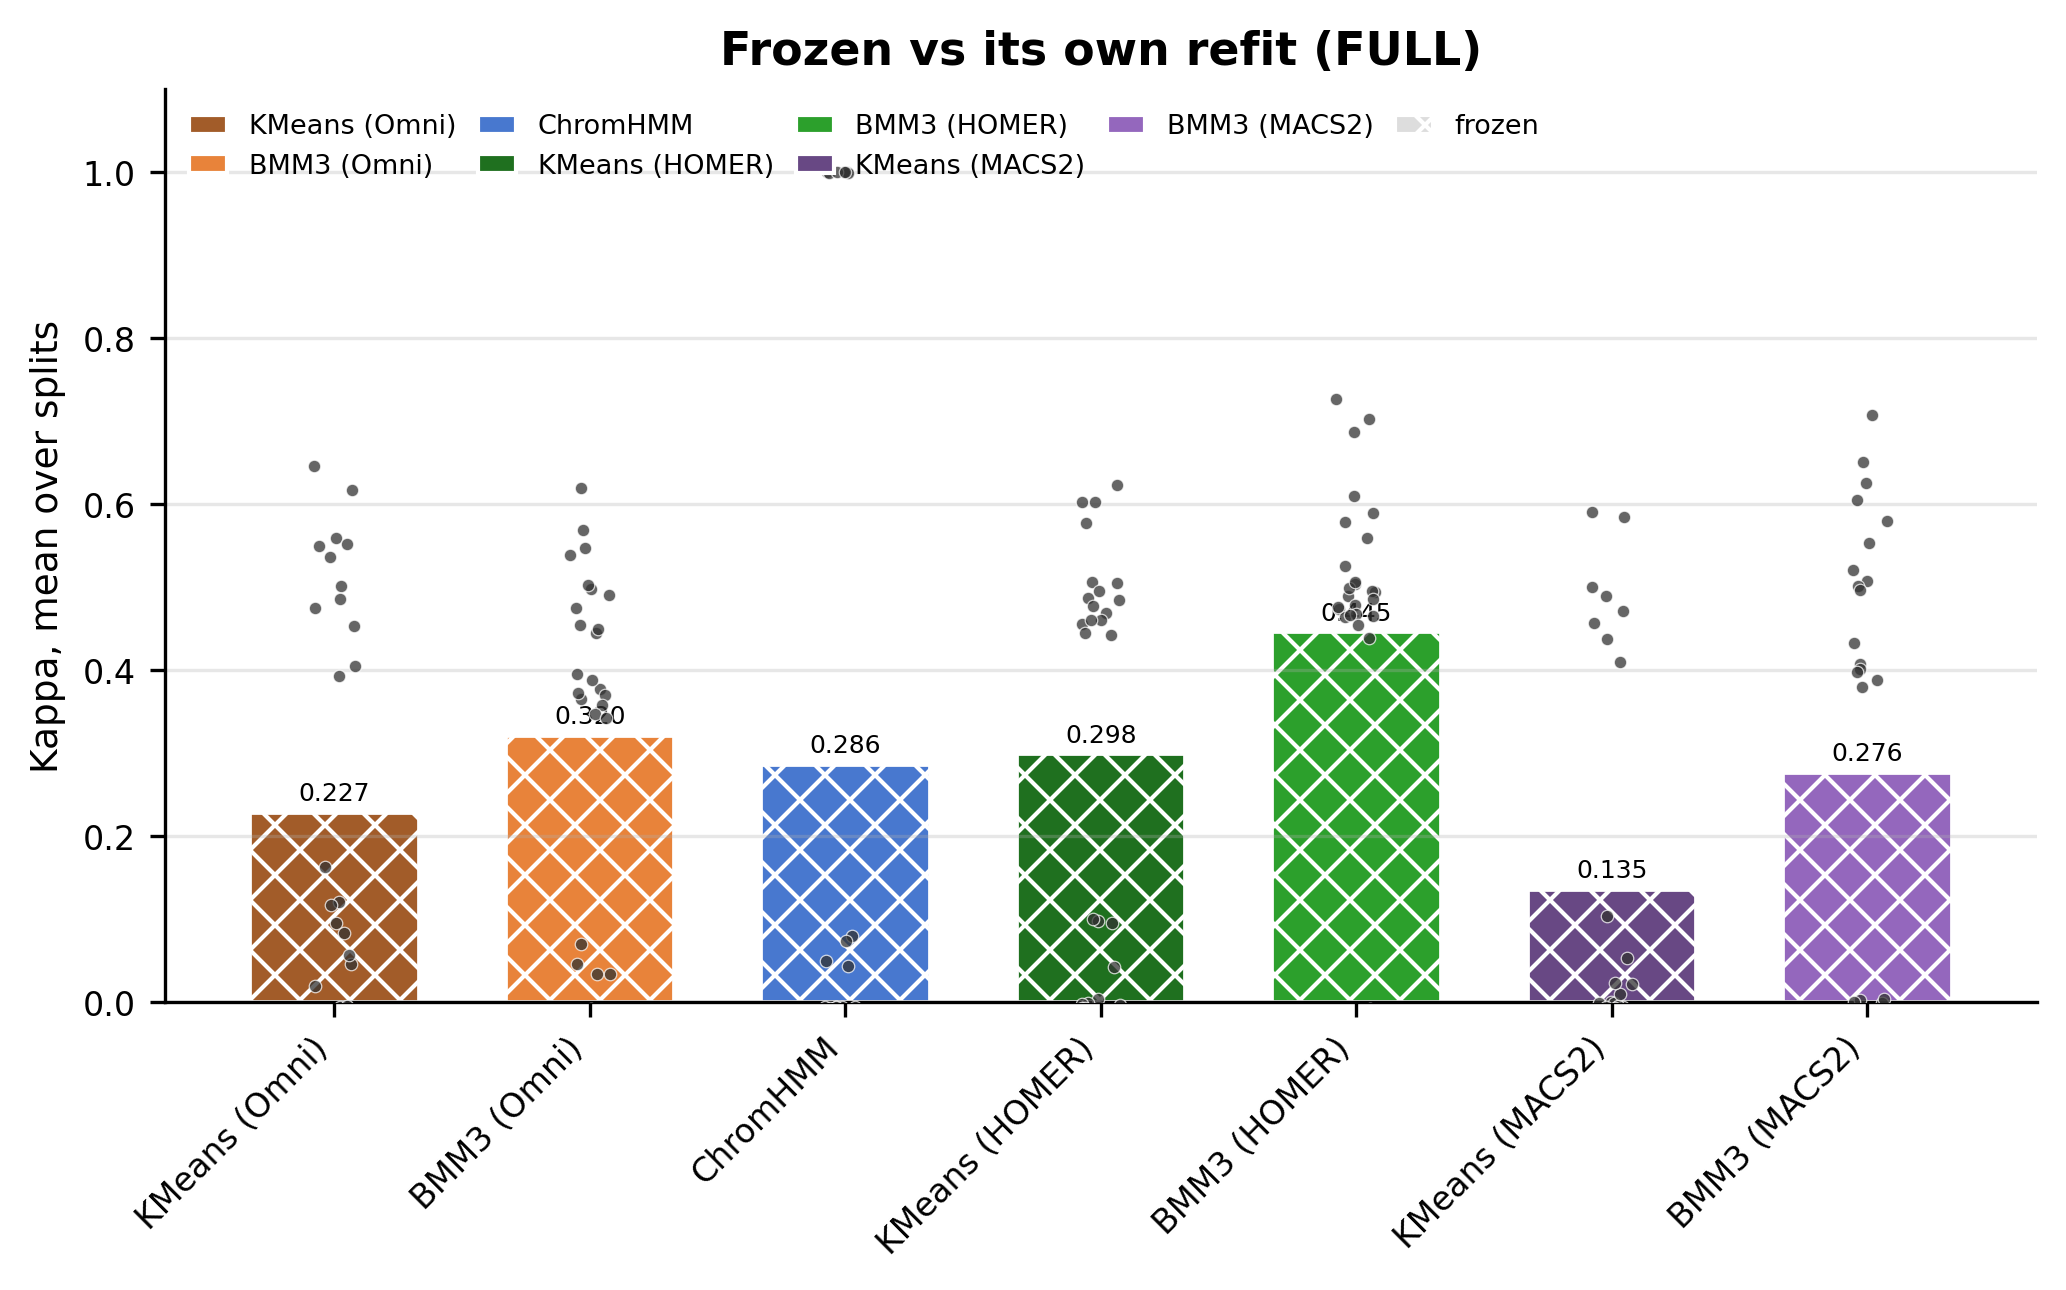

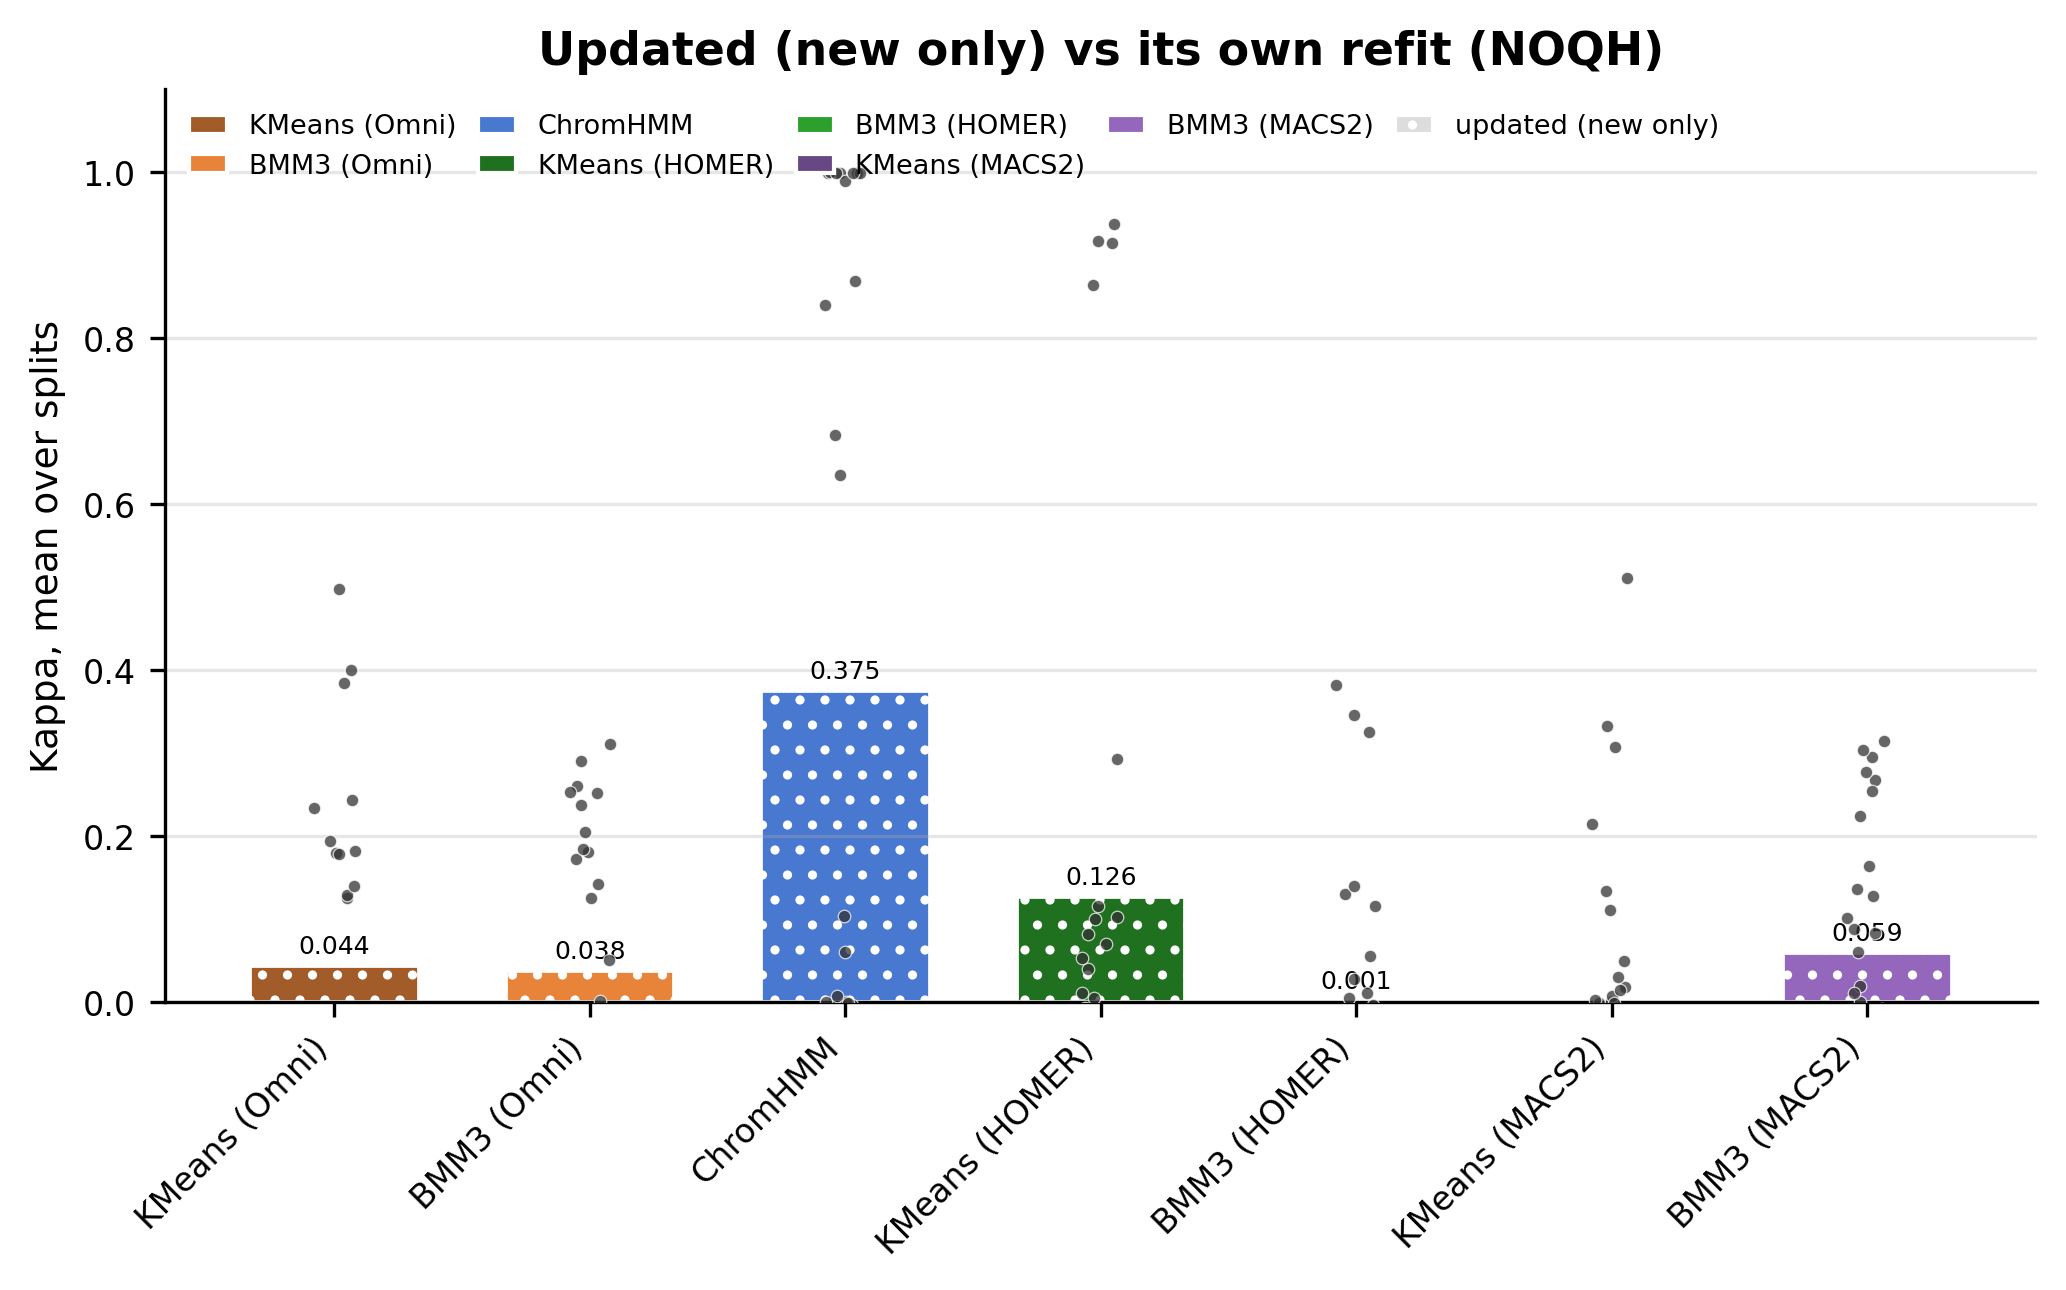

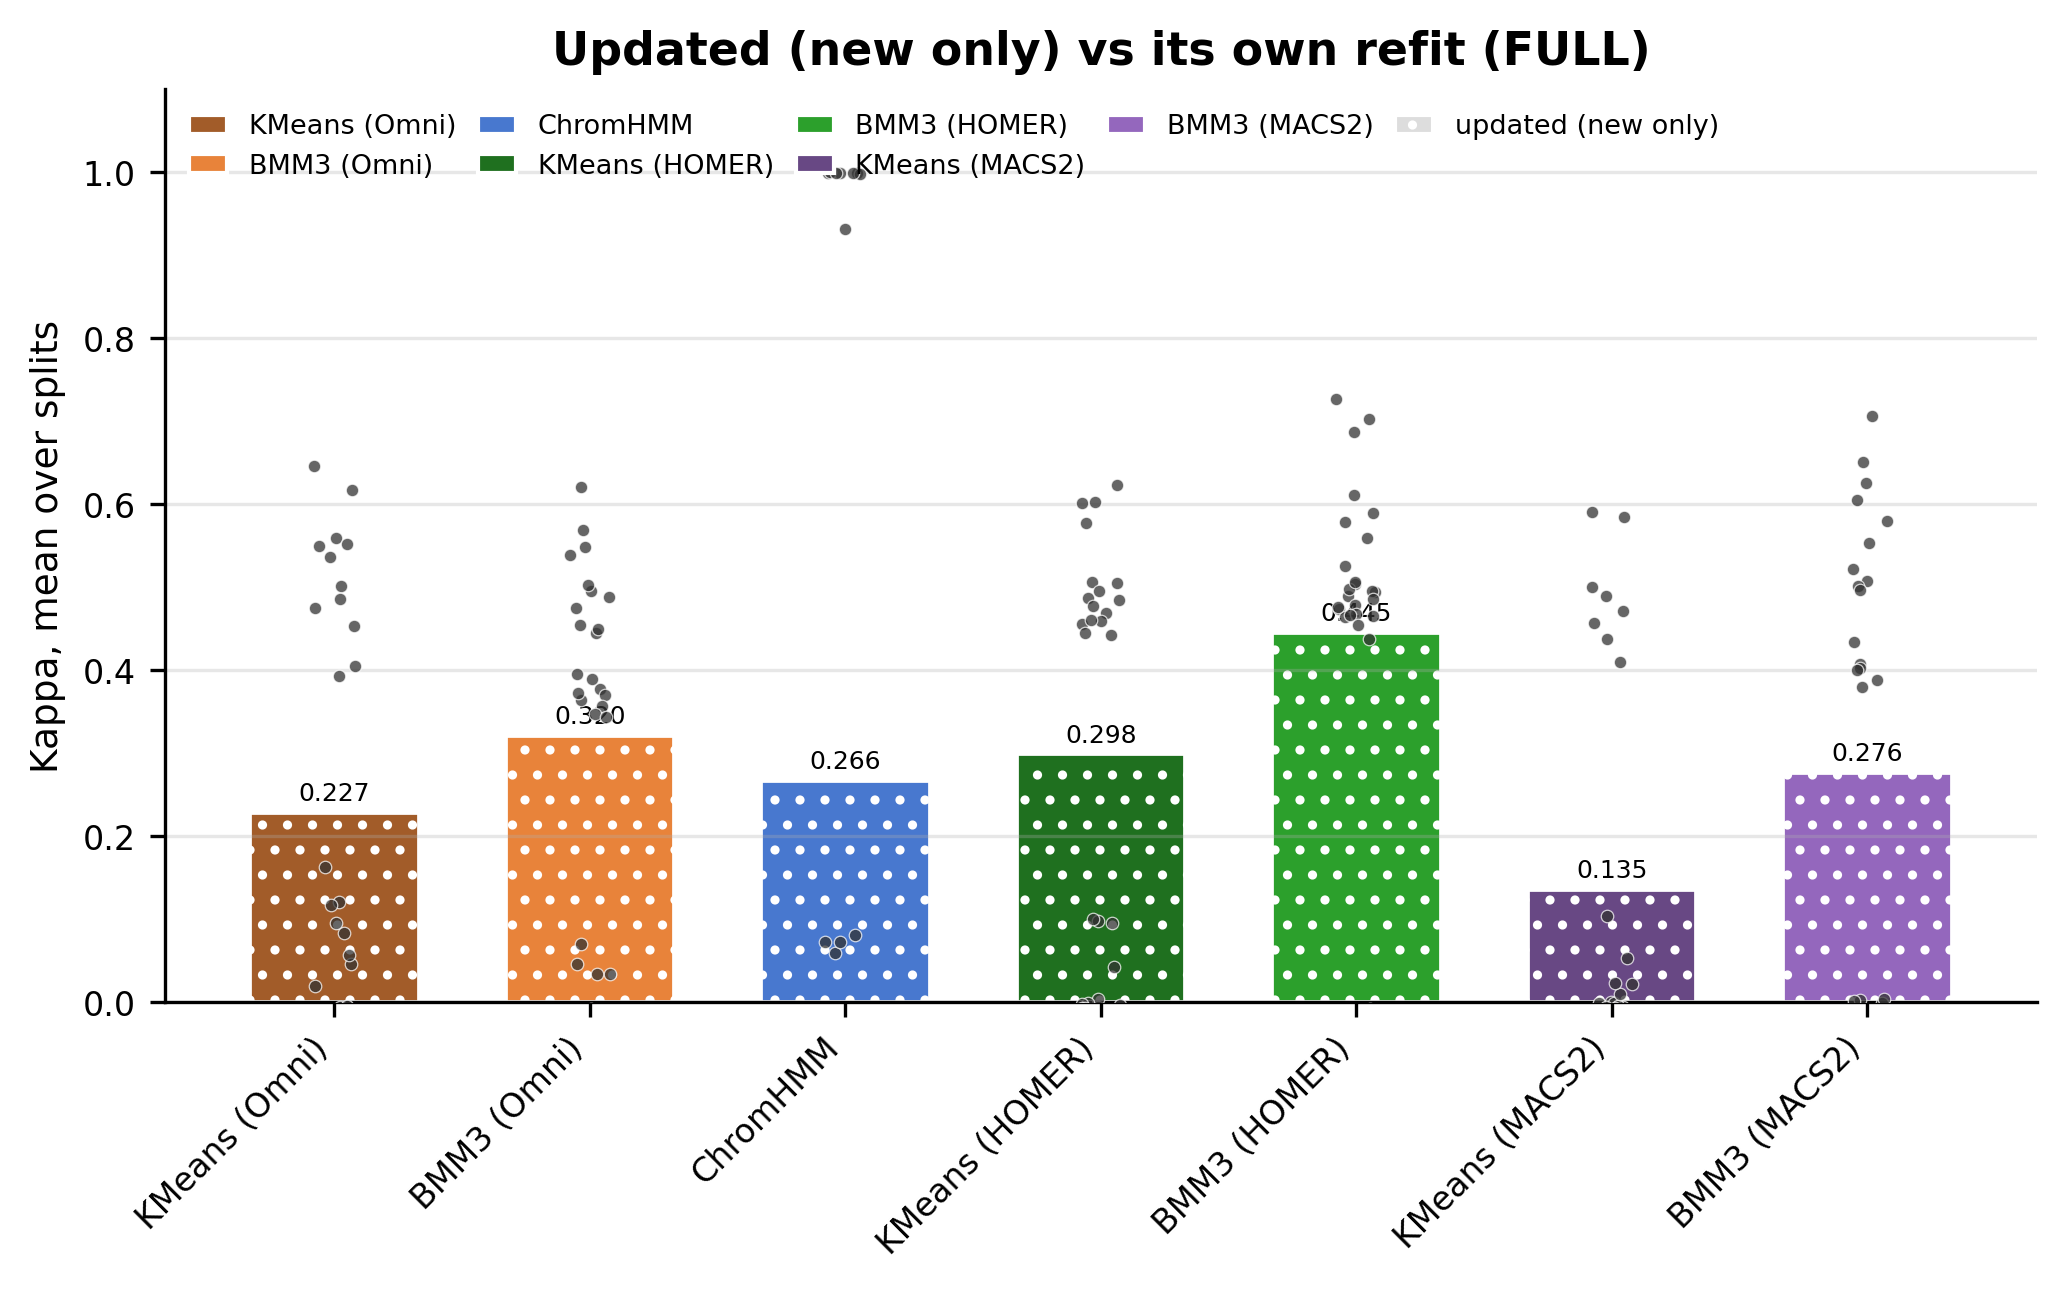

In [11]:
header("State-space stability: mean per-state agreement (Kappa) against each arm's own refit")
show_all([f"stability_{m}_{d}_{s}.png" for s in transfer.ARMS_OF_SCENARIO
          for m in ("kappa",) for d in ("noqh", "full")], base=PLOTS, width=700);

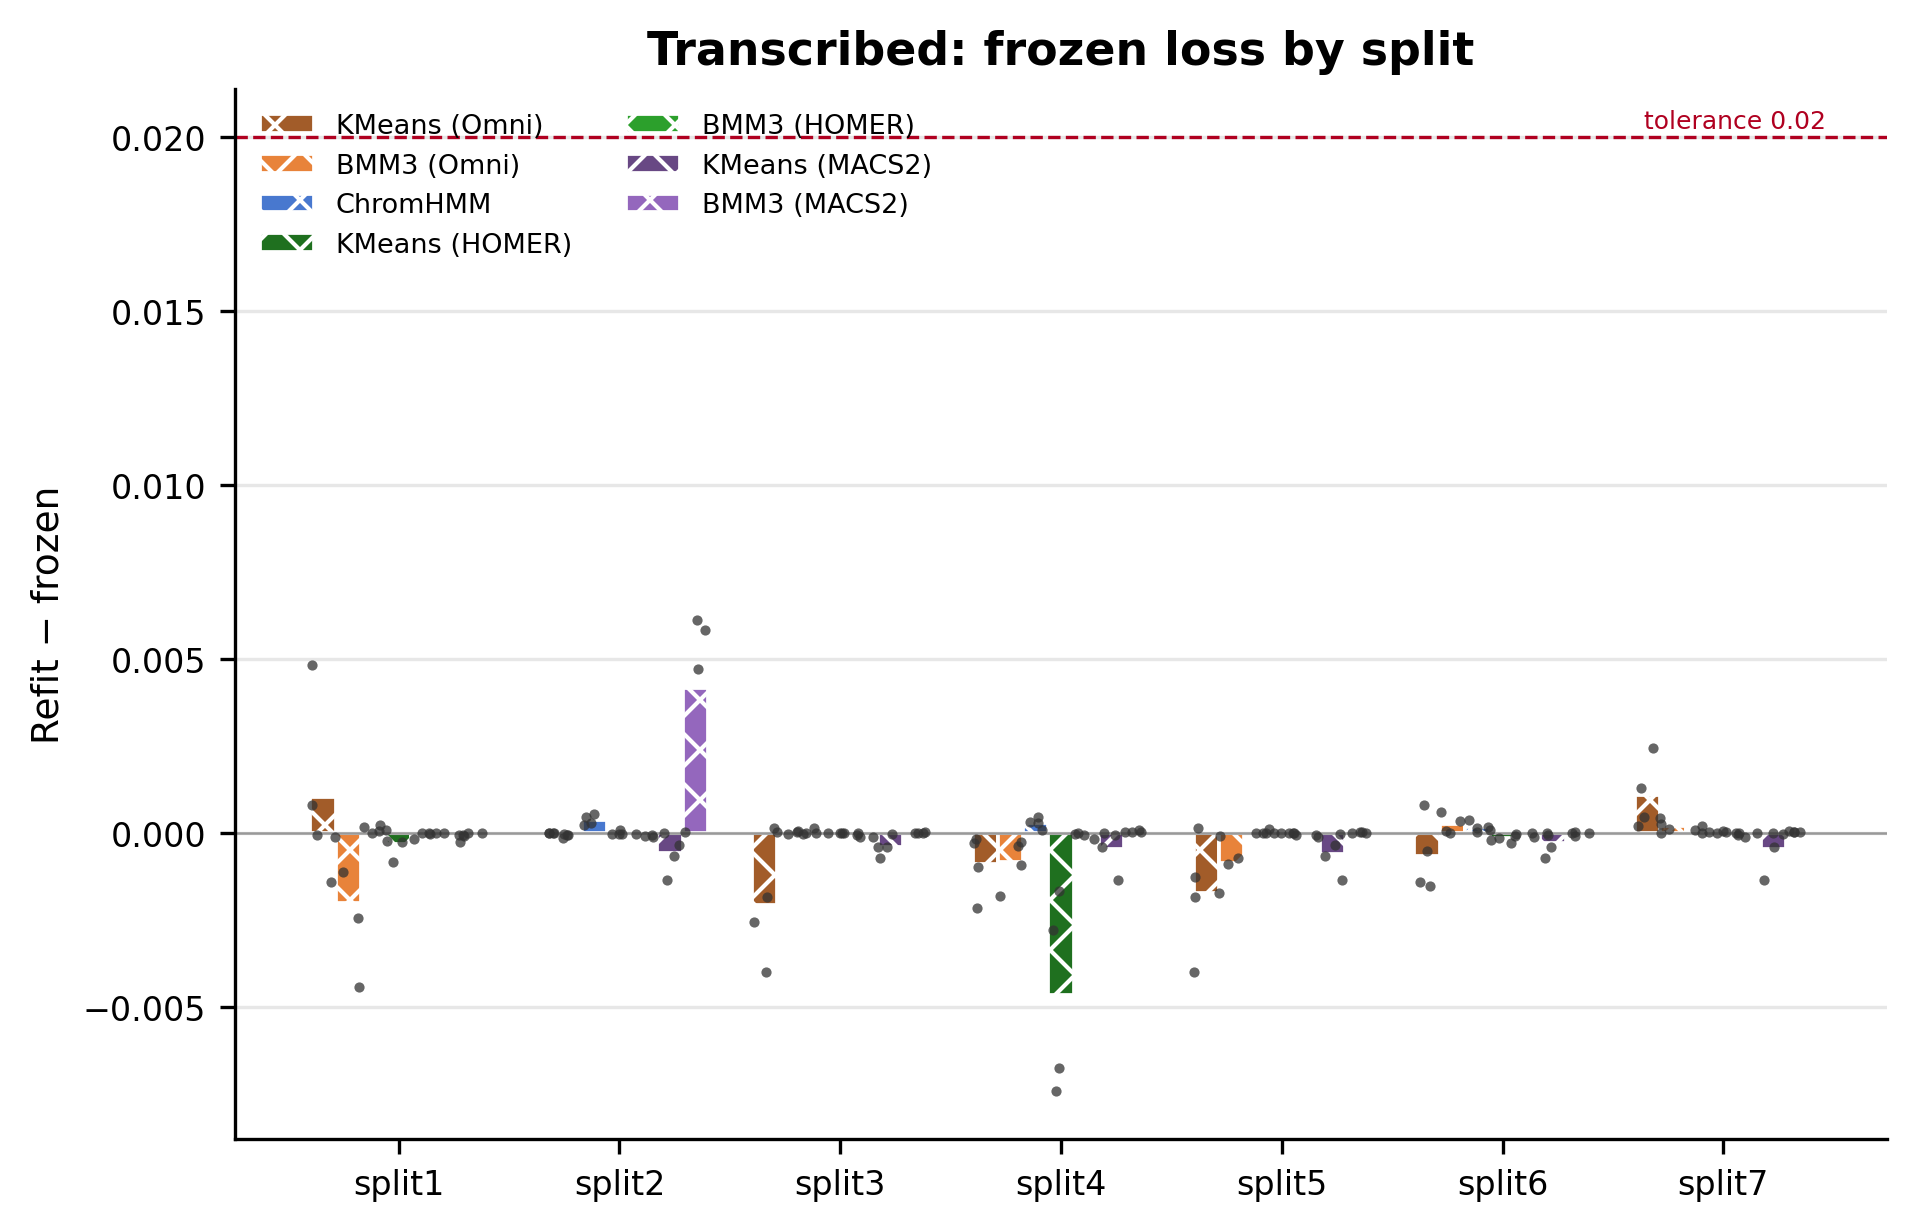

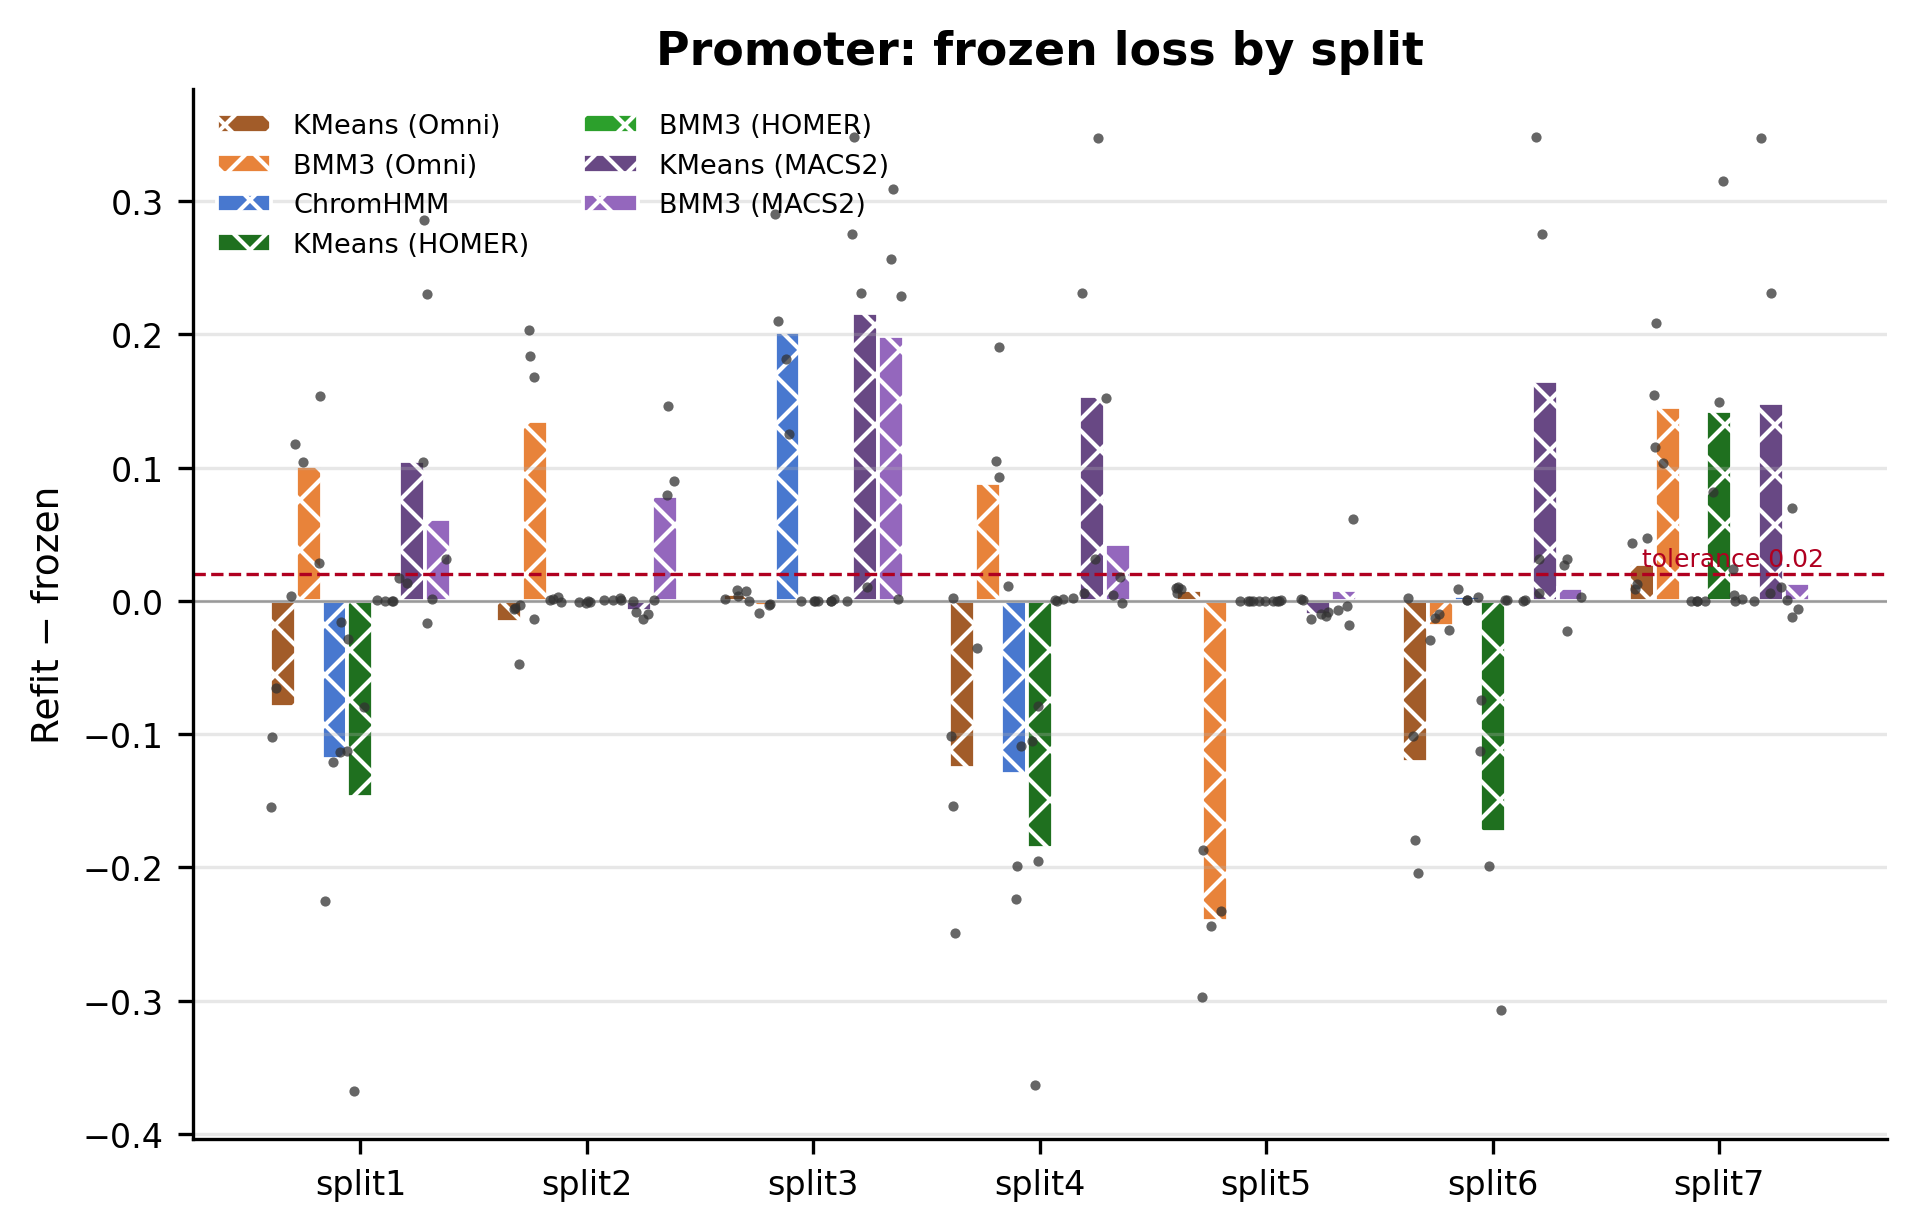

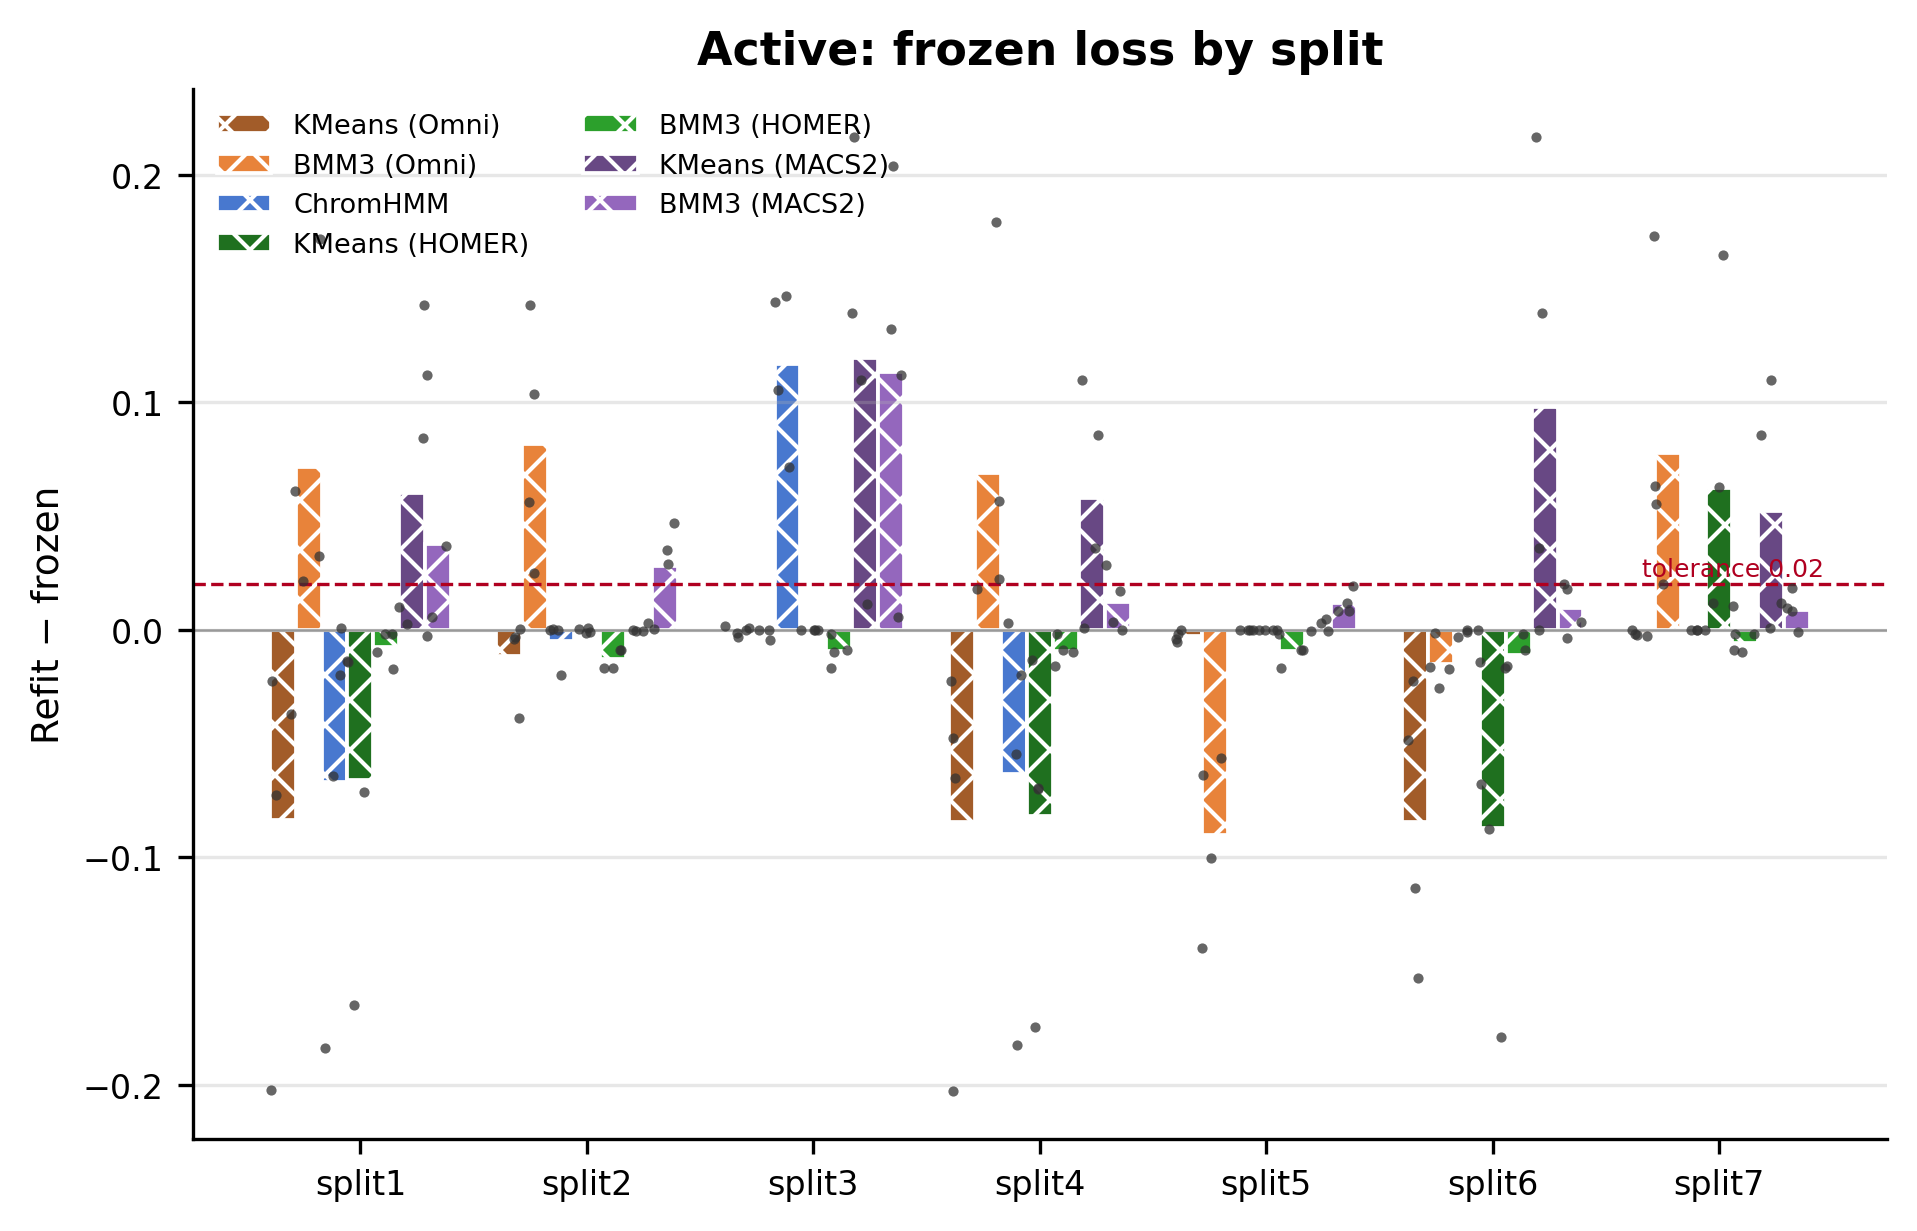

In [12]:
header("Frozen loss, split by split")
show_all([f"split_{key}.png" for key, *_ in fvr.PRIMARY], base=PLOTS, width=700);

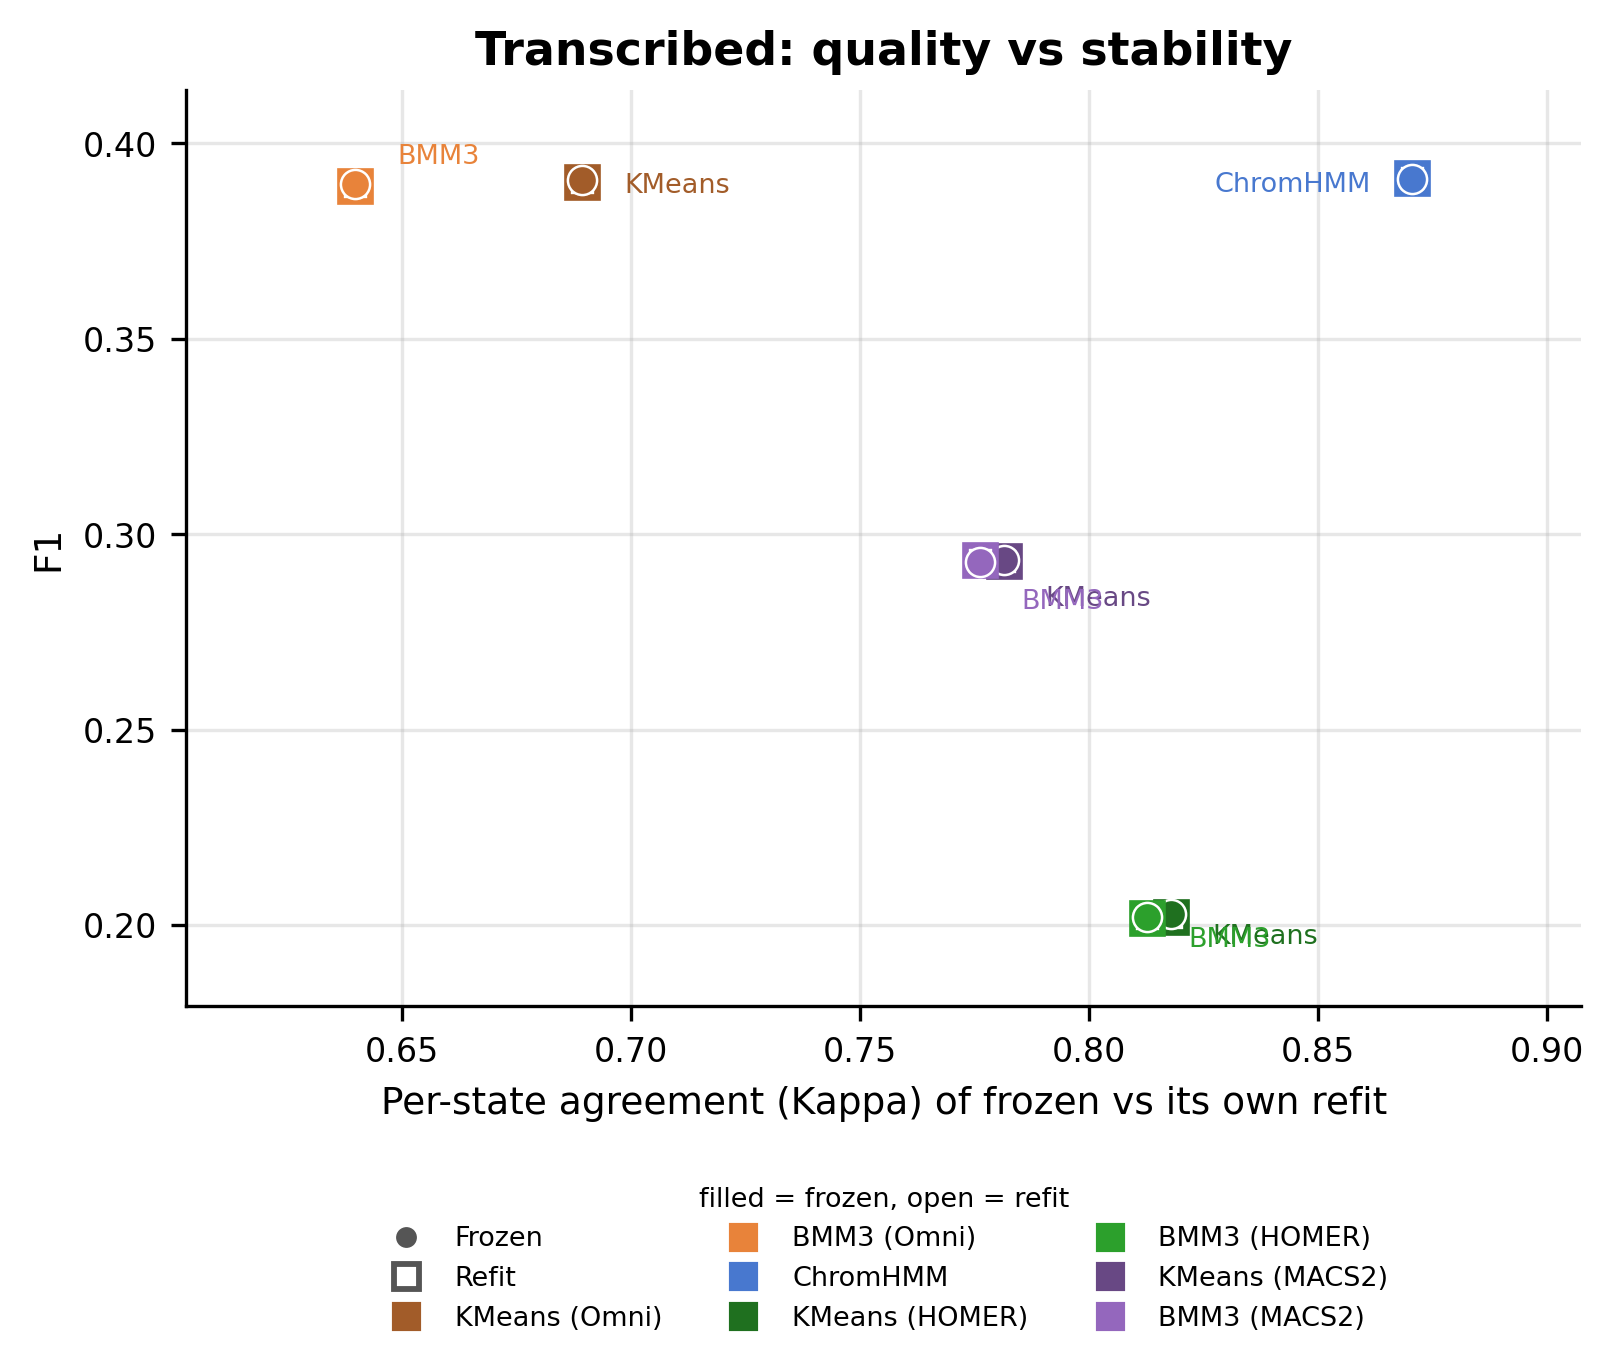

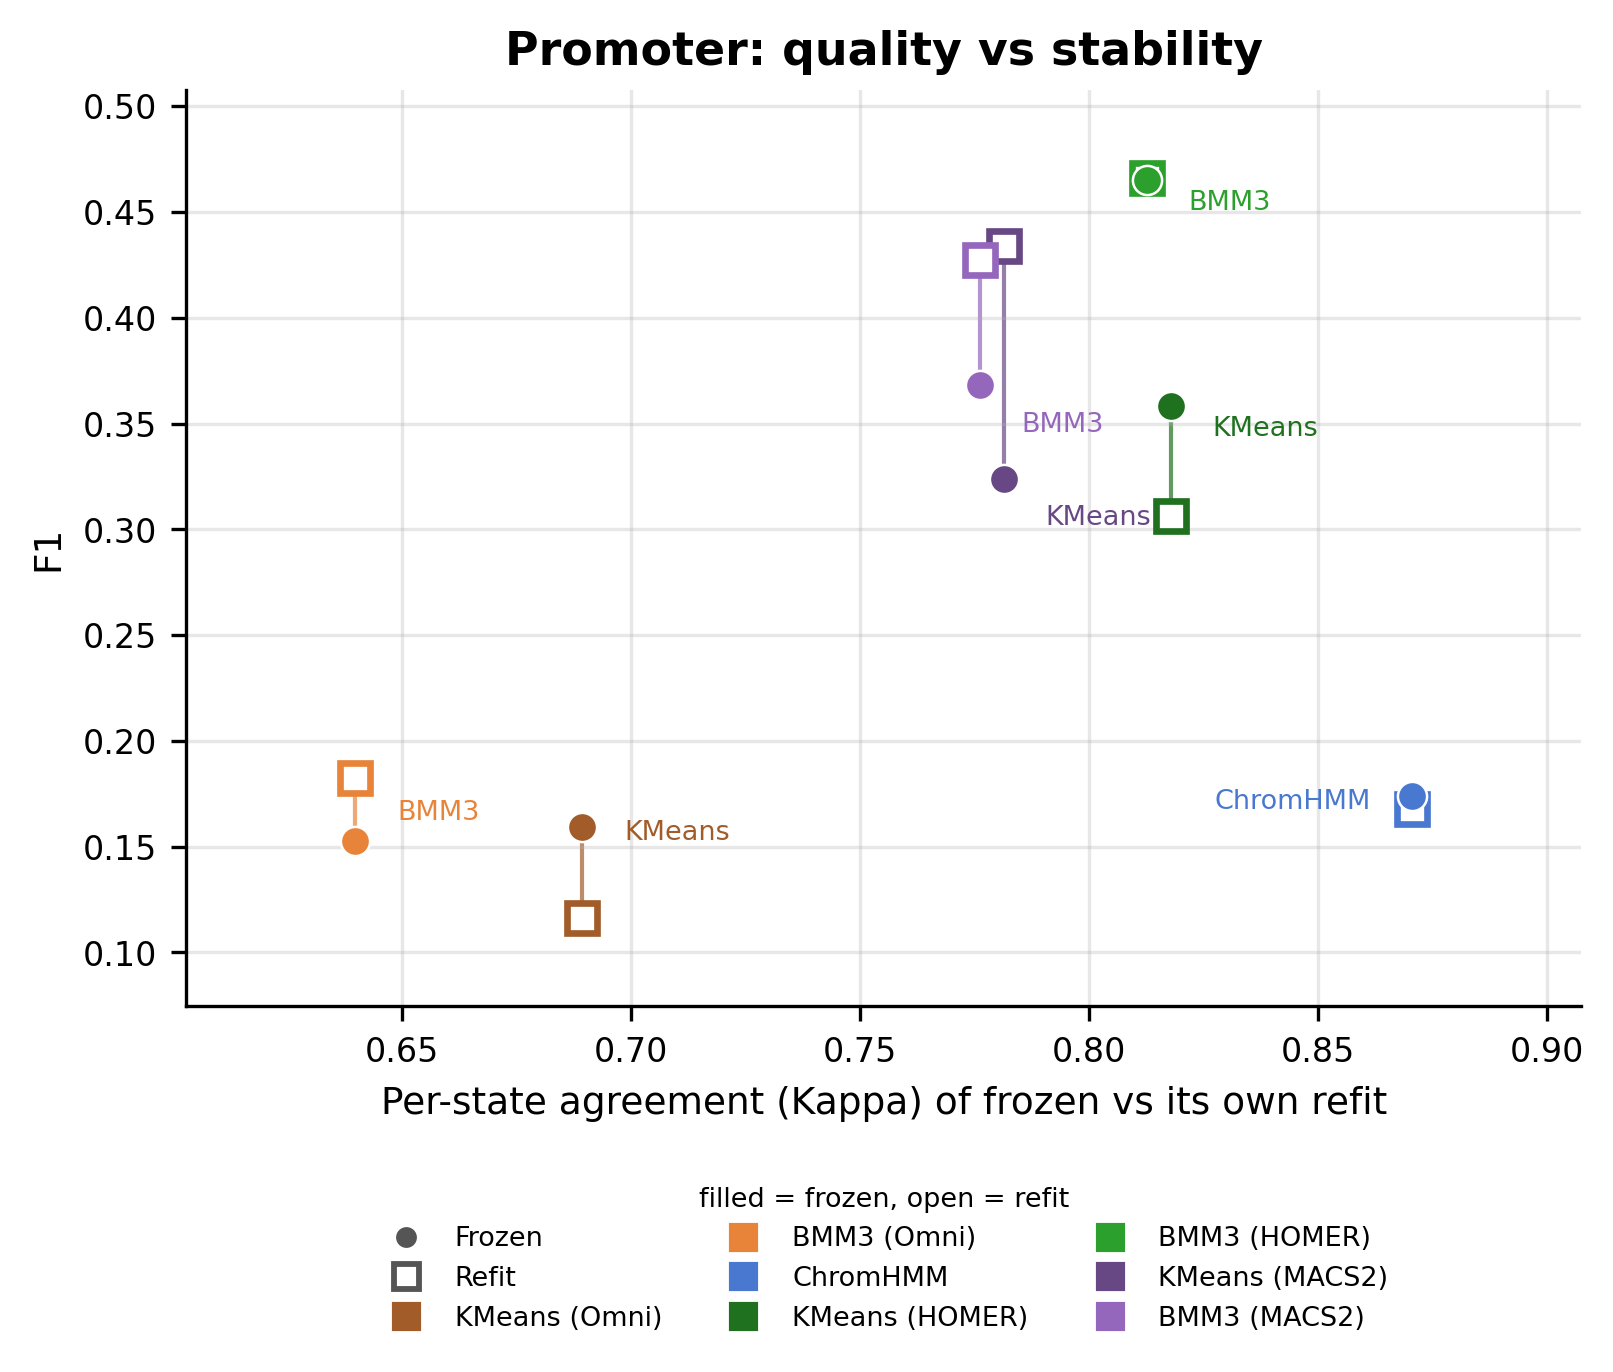

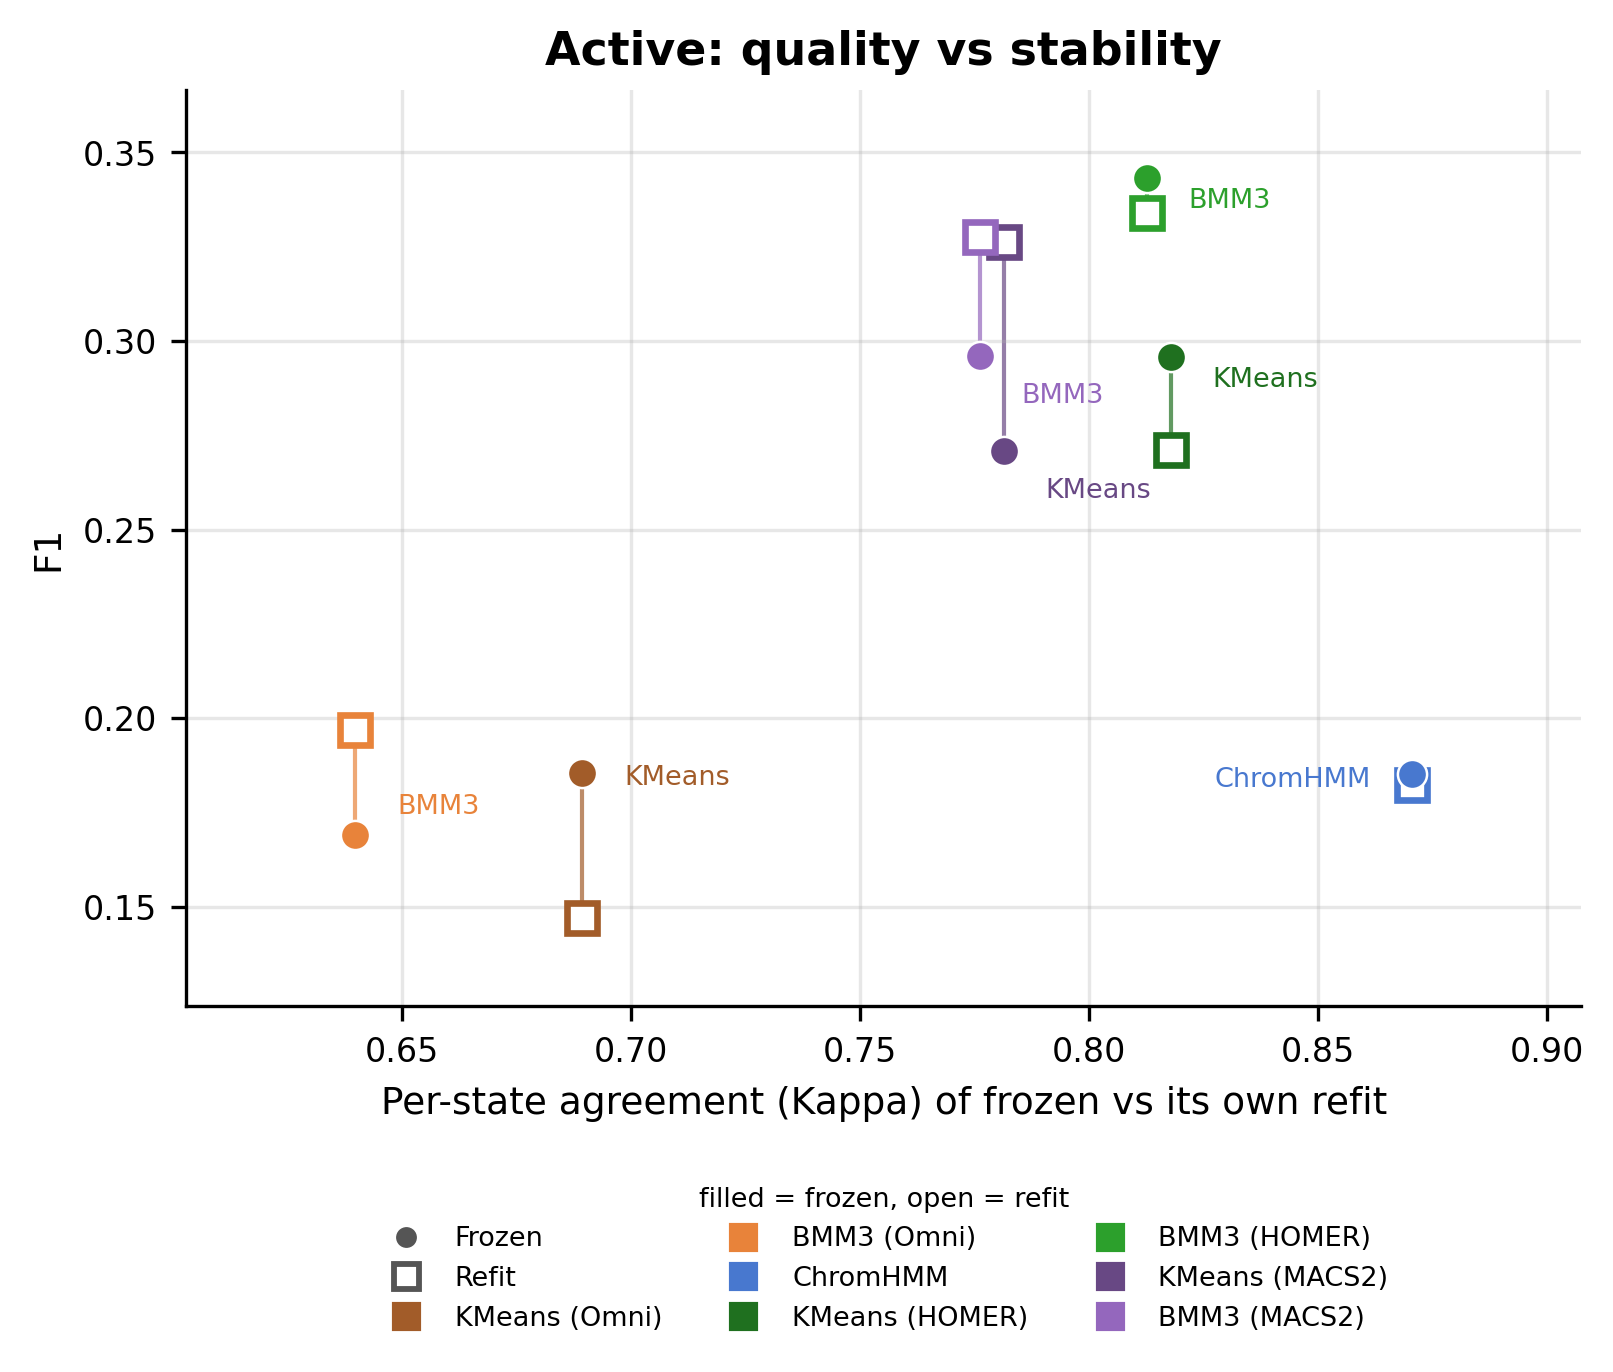

In [13]:
header("Quality against stability - the trade-off")
show_all([f"tradeoff_{key}.png" for key, *_ in fvr.PRIMARY], base=PLOTS, width=620);